# Cube-id Diffusion Pipeline

This notebook uses the cube-id diffusion changes across the Torch trainers and the MLX U-Net equivalent model family:

1. Torch conditional DDPM (`conditional_diffusion.py`)
2. Torch unconditional DDPM (`unconditional_ddpm.py`)
3. Torch guided conditional DDPM (`guided_conditional_diffusion.py`) in classifier-free and classifier-guided modes
4. Torch loop-conditioned DDPM (`loop_conditioned_diffusion.py`)
5. MLX U-Net equivalents for base, unconditional, guided classifier-free, guided classifier, and loop-conditioned DDPM (`ddpm_mlx_equivalent.py`)

The shared cube-id settings are `--rgb-encoding cube-id`, `fit_mode="cube-id-grid"`, and `channels=3`.


## 1. Setup


In [1]:
from __future__ import annotations

import importlib
import json
import shlex
import subprocess
import sys
from datetime import datetime
from dataclasses import asdict
from pathlib import Path

from IPython.display import display
from PIL import Image


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "diffusion_hash_inv").exists():
            return candidate
    raise RuntimeError("Could not find repository root from current working directory")


REPO_ROOT = find_repo_root()
SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

print(f"repo: {REPO_ROOT}")


repo: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse


In [2]:
try:
    import torch

    TORCH_AVAILABLE = True
    TORCH_DEFAULT_DEVICE = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
except Exception as exc:
    torch = None
    TORCH_AVAILABLE = False
    TORCH_DEFAULT_DEVICE = "cpu"
    print(f"Torch unavailable: {exc}")

try:
    import mlx.core as mx

    # Keep notebook checks conservative: the actual MLX model imports mlx.nn.
    mx.set_default_device(mx.cpu)
    import diffusion_hash_inv.models.conditional_diffusion_mlx as _mlx_conditional_check

    MLX_AVAILABLE = True
    MLX_DEFAULT_DEVICE = "gpu"
except Exception as exc:
    mx = None
    MLX_AVAILABLE = False
    MLX_DEFAULT_DEVICE = "cpu"
    print(f"MLX conditional model unavailable: {exc}")

print(f"torch available: {TORCH_AVAILABLE} device={TORCH_DEFAULT_DEVICE}")
print(f"mlx conditional available: {MLX_AVAILABLE} default_device={MLX_DEFAULT_DEVICE}")


torch available: True device=mps
mlx conditional available: True default_device=gpu


In [3]:
SMOKE_ITERATIONS = 64
FULL_ITERATIONS = 10000
BIT_LENGTH = 128
HASH_ALG = "md5"

RUN_HASH_GENERATION = False

# Global switches. Keep these False for selective per-job execution.
RUN_ALL_SMOKE_JOBS = False
RUN_ALL_FULL_JOBS = True

# Torch jobs: base, unconditional, guided classifier-free, guided classifier, loop-conditioned.
RUN_TORCH_BASE_SMOKE_JOB = TORCH_AVAILABLE and RUN_ALL_SMOKE_JOBS
RUN_TORCH_UNCONDITIONAL_SMOKE_JOB = TORCH_AVAILABLE and RUN_ALL_SMOKE_JOBS
RUN_TORCH_GUIDED_CFG_SMOKE_JOB = TORCH_AVAILABLE and RUN_ALL_SMOKE_JOBS
RUN_TORCH_GUIDED_CLS_SMOKE_JOB = TORCH_AVAILABLE and RUN_ALL_SMOKE_JOBS
RUN_TORCH_LOOP_SMOKE_JOB = TORCH_AVAILABLE and RUN_ALL_SMOKE_JOBS

RUN_TORCH_BASE_FULL_JOB = TORCH_AVAILABLE and RUN_ALL_FULL_JOBS
RUN_TORCH_UNCONDITIONAL_FULL_JOB = TORCH_AVAILABLE and RUN_ALL_FULL_JOBS
RUN_TORCH_GUIDED_CFG_FULL_JOB = TORCH_AVAILABLE and RUN_ALL_FULL_JOBS
RUN_TORCH_GUIDED_CLS_FULL_JOB = TORCH_AVAILABLE and RUN_ALL_FULL_JOBS
RUN_TORCH_LOOP_FULL_JOB = TORCH_AVAILABLE and RUN_ALL_FULL_JOBS

# MLX equivalent jobs. The base job can also use conditional_diffusion_mlx;
# full MLX U-Net equivalent job cells should use these exact names.
RUN_MLX_BASE_SMOKE_JOB = MLX_AVAILABLE and RUN_ALL_SMOKE_JOBS
RUN_MLX_UNCONDITIONAL_SMOKE_JOB = MLX_AVAILABLE and RUN_ALL_SMOKE_JOBS
RUN_MLX_GUIDED_CFG_SMOKE_JOB = MLX_AVAILABLE and RUN_ALL_SMOKE_JOBS
RUN_MLX_GUIDED_CLS_SMOKE_JOB = MLX_AVAILABLE and RUN_ALL_SMOKE_JOBS
RUN_MLX_LOOP_SMOKE_JOB = MLX_AVAILABLE and RUN_ALL_SMOKE_JOBS

RUN_MLX_BASE_FULL_JOB = MLX_AVAILABLE and RUN_ALL_FULL_JOBS
RUN_MLX_UNCONDITIONAL_FULL_JOB = MLX_AVAILABLE and RUN_ALL_FULL_JOBS
RUN_MLX_GUIDED_CFG_FULL_JOB = MLX_AVAILABLE and RUN_ALL_FULL_JOBS
RUN_MLX_GUIDED_CLS_FULL_JOB = MLX_AVAILABLE and RUN_ALL_FULL_JOBS
RUN_MLX_LOOP_FULL_JOB = MLX_AVAILABLE and RUN_ALL_FULL_JOBS

RUN_JOB_FLAGS = {
    "torch_base_smoke": RUN_TORCH_BASE_SMOKE_JOB,
    "torch_unconditional_smoke": RUN_TORCH_UNCONDITIONAL_SMOKE_JOB,
    "torch_guided_cfg_smoke": RUN_TORCH_GUIDED_CFG_SMOKE_JOB,
    "torch_guided_cls_smoke": RUN_TORCH_GUIDED_CLS_SMOKE_JOB,
    "torch_loop_smoke": RUN_TORCH_LOOP_SMOKE_JOB,
    "mlx_base_smoke": RUN_MLX_BASE_SMOKE_JOB,
    "mlx_unconditional_smoke": RUN_MLX_UNCONDITIONAL_SMOKE_JOB,
    "mlx_guided_cfg_smoke": RUN_MLX_GUIDED_CFG_SMOKE_JOB,
    "mlx_guided_cls_smoke": RUN_MLX_GUIDED_CLS_SMOKE_JOB,
    "mlx_loop_smoke": RUN_MLX_LOOP_SMOKE_JOB,
    "torch_base_full": RUN_TORCH_BASE_FULL_JOB,
    "torch_unconditional_full": RUN_TORCH_UNCONDITIONAL_FULL_JOB,
    "torch_guided_cfg_full": RUN_TORCH_GUIDED_CFG_FULL_JOB,
    "torch_guided_cls_full": RUN_TORCH_GUIDED_CLS_FULL_JOB,
    "torch_loop_full": RUN_TORCH_LOOP_FULL_JOB,
    "mlx_base_full": RUN_MLX_BASE_FULL_JOB,
    "mlx_unconditional_full": RUN_MLX_UNCONDITIONAL_FULL_JOB,
    "mlx_guided_cfg_full": RUN_MLX_GUIDED_CFG_FULL_JOB,
    "mlx_guided_cls_full": RUN_MLX_GUIDED_CLS_FULL_JOB,
    "mlx_loop_full": RUN_MLX_LOOP_FULL_JOB,
}


def job_enabled(name: str) -> bool:
    return bool(RUN_JOB_FLAGS.get(name, False))



def cleanup_job_memory(
    job_name: str | None = None,
    *,
    torch_enabled: bool = True,
    mlx_enabled: bool = True,
    verbose: bool = True,
) -> None:
    import gc as _gc

    _gc.collect()
    if torch_enabled and TORCH_AVAILABLE and torch is not None:
        try:
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
        except Exception as exc:
            print(f"Torch CUDA cleanup skipped: {exc!r}")
        try:
            if hasattr(torch, "mps") and hasattr(torch.mps, "is_available") and torch.mps.is_available():
                torch.mps.synchronize()
                torch.mps.empty_cache()
        except Exception as exc:
            print(f"Torch MPS cleanup skipped: {exc!r}")

    if mlx_enabled and MLX_AVAILABLE and mx is not None:
        try:
            if hasattr(mx, "clear_cache"):
                mx.clear_cache()
        except Exception as exc:
            print(f"MLX cleanup skipped: {exc!r}")

    _gc.collect()
    if verbose and job_name:
        print(f"memory cleanup completed: {job_name}")


def run_torch_job_if_enabled(job_name: str, config, train_fn, *, disabled_message: str):
    print(json.dumps(asdict(config), indent=2, default=str))
    if not job_enabled(job_name):
        print(disabled_message)
        return None
    try:
        result = train_fn(config)
        print(json.dumps(result, indent=2, default=str))
        return result
    finally:
        cleanup_job_memory(job_name, mlx_enabled=False)


def run_mlx_conditional_job_if_enabled(job_name: str, config, train_fn, *, disabled_message: str):
    print(json.dumps(asdict(config), indent=2, default=str))
    if not job_enabled(job_name):
        print(disabled_message)
        return None
    try:
        result = train_fn(config)
        print(result)
        return result
    finally:
        cleanup_job_memory(job_name, torch_enabled=False)

def show_job_flags() -> None:
    enabled = [name for name, flag in RUN_JOB_FLAGS.items() if flag]
    print(f"enabled jobs: {len(enabled)} / {len(RUN_JOB_FLAGS)}")
    for name in enabled:
        print("  RUN", name)
    if not enabled:
        print("  none; set one RUN_*_JOB flag to True or enable RUN_ALL_SMOKE_JOBS/RUN_ALL_FULL_JOBS")

DATA_ROOT = REPO_ROOT / "data" / "images"
JSON_ROOT = REPO_ROOT / "output" / "json"
NOTEBOOK_OUTPUT_DIR = REPO_ROOT / "output" / "cube_id_diffusion_notebook"
NOTEBOOK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

INCLUDE_DIFFUSION_RESULT_TIME_IN_DIR = True
DIFFUSION_RESULT_TIME_FORMAT = "%Y%m%d_%H%M%S"
_DIFFUSION_OUTPUT_DIR_CACHE: dict[str, str] = {}


def diffusion_output_name(output_name: str) -> str:
    if not INCLUDE_DIFFUSION_RESULT_TIME_IN_DIR:
        return output_name
    if output_name not in _DIFFUSION_OUTPUT_DIR_CACHE:
        run_time = datetime.now().strftime(DIFFUSION_RESULT_TIME_FORMAT)
        _DIFFUSION_OUTPUT_DIR_CACHE[output_name] = f"{output_name}_{run_time}"
    return _DIFFUSION_OUTPUT_DIR_CACHE[output_name]


def diffusion_output_dir(output_name: str) -> Path:
    return NOTEBOOK_OUTPUT_DIR / diffusion_output_name(output_name)

TORCH_SMOKE_DEVICE = "cpu"
TORCH_FULL_DEVICE = "auto"
MLX_SMOKE_DEVICE = "cpu"
MLX_FULL_DEVICE = MLX_DEFAULT_DEVICE

print(f"data root: {DATA_ROOT}")
print(f"json root: {JSON_ROOT}")
print(f"notebook output: {NOTEBOOK_OUTPUT_DIR}")
print(f"timestamped diffusion output dirs: {INCLUDE_DIFFUSION_RESULT_TIME_IN_DIR}")
show_job_flags()


data root: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data/images
json root: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/json
notebook output: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/cube_id_diffusion_notebook
timestamped diffusion output dirs: True
enabled jobs: 10 / 20
  RUN torch_base_full
  RUN torch_unconditional_full
  RUN torch_guided_cfg_full
  RUN torch_guided_cls_full
  RUN torch_loop_full
  RUN mlx_base_full
  RUN mlx_unconditional_full
  RUN mlx_guided_cfg_full
  RUN mlx_guided_cls_full
  RUN mlx_loop_full


## 2. Generate cube-id PNG data

This runs the normal hash pipeline first, then writes `message.png` artifacts with one byte encoded as one cube-id RGB block.


In [4]:
hash_cmd = [
    sys.executable,
    "-m",
    "diffusion_hash_inv.hash_main",
    "-i",
    str(SMOKE_ITERATIONS),
    "-l",
    str(BIT_LENGTH),
    "--hash-alg",
    HASH_ALG,
    "--sequential",
    "--rgb-encoding",
    "cube-id",
    "--make-png",
    "--image-workers",
    "1",
]

print(shlex.join(hash_cmd))
if RUN_HASH_GENERATION:
    try:
        subprocess.run(hash_cmd, cwd=REPO_ROOT, check=True)
    finally:
        cleanup_job_memory("hash_generation")
else:
    print("RUN_HASH_GENERATION is False; using existing data/images and output/json files.")


/Users/choisoonwook/.pyenv/versions/diffusion_hash/bin/python -m diffusion_hash_inv.hash_main -i 64 -l 128 --hash-alg md5 --sequential --rgb-encoding cube-id --make-png --image-workers 1
RUN_HASH_GENERATION is False; using existing data/images and output/json files.


In [5]:
message_pngs = sorted(DATA_ROOT.glob("*/message.png"))
json_files = sorted(JSON_ROOT.glob("**/*.json"))

print(f"message PNGs: {len(message_pngs)}")
print(f"JSON files: {len(json_files)}")
if not message_pngs:
    raise RuntimeError("No message.png files found. Run the previous cell or check DATA_ROOT.")

message_pngs[-3:]


message PNGs: 10000
JSON files: 10000


[PosixPath('/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data/images/MD5_128_2026-05-23 18-55-58.604475+09-00_09997/message.png'),
 PosixPath('/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data/images/MD5_128_2026-05-23 18-55-58.604475+09-00_09998/message.png'),
 PosixPath('/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data/images/MD5_128_2026-05-23 18-55-58.604475+09-00_09999/message.png')]

## 3. Load as cube-id-grid diffusion input

`cube-id-grid` keeps the RGB cube-id value by sampling the center pixel of each `ImgConfig.img_size` block. Use `channels=3`; grayscale would destroy the cube-id RGB mapping.


In [6]:
if not TORCH_AVAILABLE:
    raise RuntimeError("Torch is required for the PyTorch dataset and training cells.")

import diffusion_hash_inv.models.conditional_diffusion as conditional_diffusion_module

conditional_diffusion_module = importlib.reload(conditional_diffusion_module)
ConditionalDiffusionTrainConfig = conditional_diffusion_module.ConditionalDiffusionTrainConfig
GeneratedImageDataset = conditional_diffusion_module.GeneratedImageDataset
train_conditional_diffusion = conditional_diffusion_module.train_conditional_diffusion
_fit_image = conditional_diffusion_module._fit_image

dataset = GeneratedImageDataset(
    DATA_ROOT,
    json_root=JSON_ROOT,
    image_size=32,
    channels=3,
    fit_mode="cube-id-grid",
    label_source="final-hash",
    max_images=SMOKE_ITERATIONS,
)

image_tensor, label_tensor, loop_meta_tensor = dataset[0]
print(f"dataset size: {len(dataset)}")
print(f"conditions: {dataset.num_conditions}")
print(f"sample tensor shape: {tuple(image_tensor.shape)}")
print(f"sample label: {int(label_tensor)} -> {dataset.idx_to_condition[int(label_tensor)]}")
print(f"loop metadata: {loop_meta_tensor.tolist()}")


dataset size: 64
conditions: 64
sample tensor shape: (3, 4, 4)
sample label: 43 -> 0xa178c5e33c98bab21b3e3239e0698b9e
loop metadata: [0.0, 1.0, 0.0, 1.0]


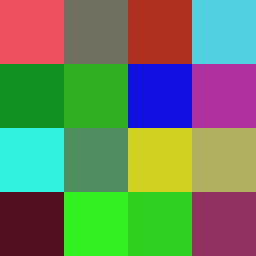

preview path: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/cube_id_diffusion_notebook/cube_id_grid_preview.png
decoded encoding: rgb-cube-id
decoded byte count: 16
decoded hex prefix: 0x575b0df22029c08df962366d0239314c


[{'index': 0,
  'x': 0,
  'y': 0,
  'rgb': [240, 80, 96],
  'bit_position': None,
  'decoded_bit': None,
  'decoded_bits': None,
  'decoded_rgb_space': None,
  'decoded_rgb_space_bits': None,
  'decoded_bit_chunk': None,
  'decoded_byte': 87,
  'decoded_byte_hex': '0x57'},
 {'index': 1,
  'x': 1,
  'y': 0,
  'rgb': [112, 112, 96],
  'bit_position': None,
  'decoded_bit': None,
  'decoded_bits': None,
  'decoded_rgb_space': None,
  'decoded_rgb_space_bits': None,
  'decoded_bit_chunk': None,
  'decoded_byte': 91,
  'decoded_byte_hex': '0x5b'},
 {'index': 2,
  'x': 2,
  'y': 0,
  'rgb': [176, 48, 32],
  'bit_position': None,
  'decoded_bit': None,
  'decoded_bits': None,
  'decoded_rgb_space': None,
  'decoded_rgb_space_bits': None,
  'decoded_bit_chunk': None,
  'decoded_byte': 13,
  'decoded_byte_hex': '0x0d'},
 {'index': 3,
  'x': 3,
  'y': 0,
  'rgb': [80, 208, 224],
  'bit_position': None,
  'decoded_bit': None,
  'decoded_bits': None,
  'decoded_rgb_space': None,
  'decoded_rgb_spa

In [7]:
from diffusion_hash_inv.models.sample_decoding import decode_sample_image

sample = dataset.samples[0]
preview_path = NOTEBOOK_OUTPUT_DIR / "cube_id_grid_preview.png"

with Image.open(sample.path) as raw_image:
    cube_id_grid = _fit_image(raw_image, image_size=32, fit_mode="cube-id-grid", channels=3)

cube_id_grid.save(preview_path)
scale = max(1, 256 // max(cube_id_grid.size))
display(cube_id_grid.resize((cube_id_grid.width * scale, cube_id_grid.height * scale), Image.Resampling.NEAREST))

decoded = decode_sample_image(preview_path, fit_mode="cube-id-grid")
print(f"preview path: {preview_path}")
print(f"decoded encoding: {decoded['encoding']}")
print(f"decoded byte count: {decoded['decoded_byte_count']}")
print(f"decoded hex prefix: {decoded['hex'][:80] if decoded['hex'] else None}")
decoded["rgb_colors"][:4]


## 4. Torch conditional DDPM smoke train

This is the base conditional DDPM using final hash labels. The important cube-id settings are `fit_mode="cube-id-grid"` and `channels=3`.


In [8]:
torch_conditional_output_dir = diffusion_output_dir("torch_conditional_smoke")
torch_conditional_config = ConditionalDiffusionTrainConfig(
    data_root=DATA_ROOT,
    json_root=JSON_ROOT,
    output_dir=torch_conditional_output_dir,
    image_size=32,
    channels=3,
    fit_mode="cube-id-grid",
    label_source="final-hash",
    max_images=SMOKE_ITERATIONS,
    batch_size=8,
    train_steps=2,
    timesteps=4,
    learning_rate=1e-3,
    base_channels=8,
    time_dim=16,
    beta_schedule="linear",
    sample_count=4,
    sample_every=0,
    checkpoint_every=0,
    save_train_batches_every=1,
    save_process_traces=True,
    device=TORCH_SMOKE_DEVICE,
    seed=0,
    log_every=1,
)

torch_conditional_result = run_torch_job_if_enabled(
    "torch_base_smoke",
    torch_conditional_config,
    train_conditional_diffusion,
    disabled_message="torch_base_smoke flag is False; set it to True to train.",
)


{
  "data_root": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data/images",
  "json_root": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/json",
  "output_dir": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/cube_id_diffusion_notebook/torch_conditional_smoke_20260525_151055",
  "image_size": 32,
  "channels": 3,
  "fit_mode": "cube-id-grid",
  "condition_mode": "json-step",
  "label_source": "final-hash",
  "max_images": 64,
  "batch_size": 8,
  "train_steps": 2,
  "epochs": null,
  "timesteps": 4,
  "learning_rate": 0.001,
  "base_channels": 8,
  "time_dim": 16,
  "beta_start": 0.0001,
  "beta_end": 0.02,
  "beta_schedule": "linear",
  "beta_values_path": null,
  "beta_schedule_step": "4th Step",
  "device": "cpu",
  "seed": 0,
  "num_workers": 0,
  "log_every": 1,
  "sample_every": 0,
  "checkpoint_every": 0,
  "sample_count": 4,
  "save_process_traces": true,
  "trace_sample_count": 4,
  "trace_steps": 8,
  "save_train_bat

In [9]:
if torch_conditional_result is None:
    decode_comparison_path = torch_conditional_output_dir / "sample" / "decode_comparison.json"
else:
    decode_comparison_path = Path(torch_conditional_result["sample_decode_comparison"])

print(f"decode comparison: {decode_comparison_path}")
if decode_comparison_path.exists():
    comparison = json.loads(decode_comparison_path.read_text(encoding="utf-8"))
    summary_keys = [
        "total",
        "decoded_byte_comparable",
        "decoded_byte_matches",
        "decoded_byte_all_match",
    ]
    print(json.dumps({key: comparison.get(key) for key in summary_keys}, indent=2))
    first_record = comparison["records"][0]
    print("source encoding:", first_record["source"]["encoding"])
    print("final encoding:", first_record["final"]["encoding"])
    print("hamming bits:", first_record["decoded_byte_hamming_distance_bits"])
else:
    print("No decode comparison found yet. Run the Torch conditional smoke train cell first.")


decode comparison: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/cube_id_diffusion_notebook/torch_conditional_smoke_20260525_151055/sample/decode_comparison.json
No decode comparison found yet. Run the Torch conditional smoke train cell first.


## 5. Torch unconditional, guided, and loop-conditioned smoke trains

These cells exercise the remaining three Torch diffusion model entry points with the same cube-id image preprocessing.


In [10]:
if not TORCH_AVAILABLE:
    raise RuntimeError("Torch is required for the Torch diffusion smoke cells.")

import diffusion_hash_inv.models.unconditional_ddpm as unconditional_ddpm_module
import diffusion_hash_inv.models.guided_conditional_diffusion as guided_conditional_diffusion_module
import diffusion_hash_inv.models.loop_conditioned_diffusion as loop_conditioned_diffusion_module

unconditional_ddpm_module = importlib.reload(unconditional_ddpm_module)
guided_conditional_diffusion_module = importlib.reload(guided_conditional_diffusion_module)
loop_conditioned_diffusion_module = importlib.reload(loop_conditioned_diffusion_module)

UnconditionalDDPMTrainConfig = unconditional_ddpm_module.UnconditionalDDPMTrainConfig
GuidedConditionalDiffusionTrainConfig = guided_conditional_diffusion_module.GuidedConditionalDiffusionTrainConfig
LoopConditionedDiffusionTrainConfig = loop_conditioned_diffusion_module.LoopConditionedDiffusionTrainConfig
train_unconditional_ddpm = unconditional_ddpm_module.train_unconditional_ddpm
train_guided_conditional_diffusion = guided_conditional_diffusion_module.train_guided_conditional_diffusion
train_loop_conditioned_diffusion = loop_conditioned_diffusion_module.train_loop_conditioned_diffusion


### 5.1 Torch unconditional DDPM smoke job


In [11]:
torch_unconditional_config = UnconditionalDDPMTrainConfig(
    data_root=DATA_ROOT,
    json_root=JSON_ROOT,
    output_dir=diffusion_output_dir("torch_unconditional_smoke"),
    image_size=32,
    channels=3,
    fit_mode="cube-id-grid",
    max_images=SMOKE_ITERATIONS,
    batch_size=8,
    train_steps=2,
    timesteps=4,
    learning_rate=1e-3,
    base_channels=8,
    time_dim=16,
    beta_schedule="linear",
    sample_count=4,
    sample_every=0,
    checkpoint_every=0,
    save_train_batches_every=1,
    save_process_traces=True,
    device=TORCH_SMOKE_DEVICE,
    seed=0,
    log_every=1,
)

torch_unconditional_result = run_torch_job_if_enabled(
    "torch_unconditional_smoke",
    torch_unconditional_config,
    train_unconditional_ddpm,
    disabled_message="torch_unconditional_smoke flag is False; set it to True to train.",
)


{
  "data_root": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data/images",
  "json_root": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/json",
  "output_dir": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/cube_id_diffusion_notebook/torch_unconditional_smoke_20260525_151056",
  "image_size": 32,
  "channels": 3,
  "fit_mode": "cube-id-grid",
  "max_images": 64,
  "batch_size": 8,
  "train_steps": 2,
  "epochs": null,
  "timesteps": 4,
  "learning_rate": 0.001,
  "base_channels": 8,
  "time_dim": 16,
  "beta_start": 0.0001,
  "beta_end": 0.02,
  "beta_schedule": "linear",
  "beta_values_path": null,
  "beta_schedule_step": "4th Step",
  "device": "cpu",
  "seed": 0,
  "num_workers": 0,
  "log_every": 1,
  "sample_every": 0,
  "checkpoint_every": 0,
  "sample_count": 4,
  "save_train_batches_every": 1,
  "save_process_traces": true,
  "trace_sample_count": 4
}
torch_unconditional_smoke flag is False; set it to True to train.


### 5.2 Torch guided conditional DDPM smoke job


In [12]:
torch_guided_config = GuidedConditionalDiffusionTrainConfig(
    data_root=DATA_ROOT,
    json_root=JSON_ROOT,
    output_dir=diffusion_output_dir("torch_guided_smoke"),
    image_size=32,
    channels=3,
    fit_mode="cube-id-grid",
    label_source="final-hash",
    max_images=SMOKE_ITERATIONS,
    batch_size=8,
    train_steps=2,
    timesteps=4,
    learning_rate=1e-3,
    base_channels=8,
    time_dim=16,
    beta_schedule="linear",
    sample_count=4,
    sample_every=0,
    checkpoint_every=0,
    save_train_batches_every=1,
    save_process_traces=True,
    device=TORCH_SMOKE_DEVICE,
    seed=0,
    log_every=1,
    guidance_mode="classifier-free",
    guidance_scale=2.0,
    condition_dropout=0.1,
    classifier_base_channels=8,
    classifier_learning_rate=1e-3,
)

torch_guided_result = run_torch_job_if_enabled(
    "torch_guided_cfg_smoke",
    torch_guided_config,
    train_guided_conditional_diffusion,
    disabled_message="torch_guided_cfg_smoke flag is False; set it to True to train.",
)


{
  "data_root": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data/images",
  "json_root": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/json",
  "output_dir": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/cube_id_diffusion_notebook/torch_guided_smoke_20260525_151056",
  "image_size": 32,
  "channels": 3,
  "fit_mode": "cube-id-grid",
  "condition_mode": "json-step",
  "label_source": "final-hash",
  "max_images": 64,
  "batch_size": 8,
  "train_steps": 2,
  "epochs": null,
  "timesteps": 4,
  "learning_rate": 0.001,
  "base_channels": 8,
  "time_dim": 16,
  "beta_start": 0.0001,
  "beta_end": 0.02,
  "beta_schedule": "linear",
  "beta_values_path": null,
  "beta_schedule_step": "4th Step",
  "device": "cpu",
  "seed": 0,
  "num_workers": 0,
  "log_every": 1,
  "sample_every": 0,
  "checkpoint_every": 0,
  "sample_count": 4,
  "save_process_traces": true,
  "trace_sample_count": 4,
  "trace_steps": 8,
  "save_train_batches_

### 5.3 Torch guided classifier DDPM smoke job


In [13]:
torch_guided_cls_config = GuidedConditionalDiffusionTrainConfig(
    data_root=DATA_ROOT,
    json_root=JSON_ROOT,
    output_dir=diffusion_output_dir("torch_guided_classifier_smoke"),
    image_size=32,
    channels=3,
    fit_mode="cube-id-grid",
    label_source="final-hash",
    max_images=SMOKE_ITERATIONS,
    batch_size=8,
    train_steps=2,
    timesteps=4,
    learning_rate=1e-3,
    base_channels=8,
    time_dim=16,
    beta_schedule="linear",
    sample_count=4,
    sample_every=0,
    checkpoint_every=0,
    save_train_batches_every=1,
    save_process_traces=True,
    device=TORCH_SMOKE_DEVICE,
    seed=0,
    log_every=1,
    guidance_mode="classifier",
    guidance_scale=1.0,
    condition_dropout=0.0,
    classifier_base_channels=8,
    classifier_learning_rate=1e-3,
)

torch_guided_cls_result = run_torch_job_if_enabled(
    "torch_guided_cls_smoke",
    torch_guided_cls_config,
    train_guided_conditional_diffusion,
    disabled_message="torch_guided_cls_smoke flag is False; set it to True to train.",
)


{
  "data_root": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data/images",
  "json_root": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/json",
  "output_dir": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/cube_id_diffusion_notebook/torch_guided_classifier_smoke_20260525_151056",
  "image_size": 32,
  "channels": 3,
  "fit_mode": "cube-id-grid",
  "condition_mode": "json-step",
  "label_source": "final-hash",
  "max_images": 64,
  "batch_size": 8,
  "train_steps": 2,
  "epochs": null,
  "timesteps": 4,
  "learning_rate": 0.001,
  "base_channels": 8,
  "time_dim": 16,
  "beta_start": 0.0001,
  "beta_end": 0.02,
  "beta_schedule": "linear",
  "beta_values_path": null,
  "beta_schedule_step": "4th Step",
  "device": "cpu",
  "seed": 0,
  "num_workers": 0,
  "log_every": 1,
  "sample_every": 0,
  "checkpoint_every": 0,
  "sample_count": 4,
  "save_process_traces": true,
  "trace_sample_count": 4,
  "trace_steps": 8,
  "save_tra

### 5.4 Torch loop-conditioned DDPM smoke job


In [14]:
torch_loop_config = LoopConditionedDiffusionTrainConfig(
    data_root=DATA_ROOT,
    json_root=JSON_ROOT,
    output_dir=diffusion_output_dir("torch_loop_conditioned_smoke"),
    image_size=32,
    channels=3,
    fit_mode="cube-id-grid",
    max_images=SMOKE_ITERATIONS,
    batch_size=8,
    train_steps=2,
    timesteps=4,
    learning_rate=1e-3,
    base_channels=8,
    time_dim=16,
    beta_schedule="linear",
    sample_count=4,
    sample_every=0,
    checkpoint_every=0,
    save_process_traces=True,
    device=TORCH_SMOKE_DEVICE,
    seed=0,
    log_every=1,
    condition_step="4th Step",
    condition_round="1st Round",
    loop_count=64,
)

torch_loop_result = run_torch_job_if_enabled(
    "torch_loop_smoke",
    torch_loop_config,
    train_loop_conditioned_diffusion,
    disabled_message="torch_loop_smoke flag is False; set it to True to train.",
)


{
  "data_root": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data/images",
  "json_root": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/json",
  "output_dir": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/cube_id_diffusion_notebook/torch_loop_conditioned_smoke_20260525_151056",
  "image_size": 32,
  "channels": 3,
  "fit_mode": "cube-id-grid",
  "condition_mode": "json-step",
  "label_source": "final-hash",
  "max_images": 64,
  "batch_size": 8,
  "train_steps": 2,
  "epochs": null,
  "timesteps": 4,
  "learning_rate": 0.001,
  "base_channels": 8,
  "time_dim": 16,
  "beta_start": 0.0001,
  "beta_end": 0.02,
  "beta_schedule": "linear",
  "beta_values_path": null,
  "beta_schedule_step": "4th Step",
  "device": "cpu",
  "seed": 0,
  "num_workers": 0,
  "log_every": 1,
  "sample_every": 0,
  "checkpoint_every": 0,
  "sample_count": 4,
  "save_process_traces": true,
  "trace_sample_count": 4,
  "trace_steps": 8,
  "save_trai

## 6. MLX conditional DDPM smoke train

This exercises the MLX conditional diffusion entry point with the same cube-id settings. The cell runs when MLX is installed and `RUN_MLX_BASE_SMOKE_JOB` is `True`.


### 6.1 MLX base conditional DDPM smoke job


In [15]:
mlx_conditional_result = None
if MLX_AVAILABLE:
    import diffusion_hash_inv.models.conditional_diffusion_mlx as mlx_conditional_diffusion_module

    mlx_conditional_diffusion_module = importlib.reload(mlx_conditional_diffusion_module)
    MLXConditionalDiffusionTrainConfig = mlx_conditional_diffusion_module.MLXConditionalDiffusionTrainConfig
    train_conditional_diffusion_mlx = mlx_conditional_diffusion_module.train_conditional_diffusion_mlx

    mlx_conditional_config = MLXConditionalDiffusionTrainConfig(
        data_root=DATA_ROOT,
        json_root=JSON_ROOT,
        output_dir=diffusion_output_dir("mlx_conditional_smoke"),
        image_size=32,
        channels=3,
        fit_mode="cube-id-grid",
        max_images=SMOKE_ITERATIONS,
        batch_size=8,
        train_steps=2,
        timesteps=4,
        hidden_dim=32,
        time_dim=16,
        beta_schedule="linear",
        sample_count=4,
        sample_every=0,
        checkpoint_every=0,
        device=MLX_SMOKE_DEVICE,
        log_every=1,
    )
    mlx_conditional_result = run_mlx_conditional_job_if_enabled(
        "mlx_base_smoke",
        mlx_conditional_config,
        train_conditional_diffusion_mlx,
        disabled_message="mlx_base_smoke flag is False; skipping MLX conditional smoke train.",
    )
else:
    print("MLX is not installed in this environment; skipping MLX conditional smoke train.")


{
  "data_root": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data/images",
  "json_root": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/json",
  "output_dir": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/cube_id_diffusion_notebook/mlx_conditional_smoke_20260525_151056",
  "image_size": 32,
  "channels": 3,
  "fit_mode": "cube-id-grid",
  "label_source": "final-hash",
  "max_images": 64,
  "batch_size": 8,
  "train_steps": 2,
  "timesteps": 4,
  "learning_rate": 0.001,
  "time_dim": 16,
  "hidden_dim": 32,
  "beta_start": 0.0001,
  "beta_end": 0.02,
  "beta_schedule": "linear",
  "beta_values_path": null,
  "beta_schedule_step": "4th Step",
  "device": "cpu",
  "seed": 0,
  "log_every": 1,
  "sample_every": 0,
  "checkpoint_every": 0,
  "sample_count": 4,
  "save_process_traces": false,
  "trace_sample_count": 4,
  "columns": 4,
  "sample_name": "final.png",
  "source_name": "source.png"
}
mlx_base_smoke flag is False; ski

## 7. Full training configurations by job

Set shared full-training values once in the common config cell, then run individual job cells. Each job cell only adds its output path and model-specific overrides.


In [16]:
if not TORCH_AVAILABLE:
    raise RuntimeError("Torch is required for the Torch full training configs.")

# Reload here so full job cells work even if smoke job cells were skipped.
import diffusion_hash_inv.models.conditional_diffusion as conditional_diffusion_module
import diffusion_hash_inv.models.unconditional_ddpm as unconditional_ddpm_module
import diffusion_hash_inv.models.guided_conditional_diffusion as guided_conditional_diffusion_module
import diffusion_hash_inv.models.loop_conditioned_diffusion as loop_conditioned_diffusion_module

conditional_diffusion_module = importlib.reload(conditional_diffusion_module)
unconditional_ddpm_module = importlib.reload(unconditional_ddpm_module)
guided_conditional_diffusion_module = importlib.reload(guided_conditional_diffusion_module)
loop_conditioned_diffusion_module = importlib.reload(loop_conditioned_diffusion_module)

ConditionalDiffusionTrainConfig = conditional_diffusion_module.ConditionalDiffusionTrainConfig
UnconditionalDDPMTrainConfig = unconditional_ddpm_module.UnconditionalDDPMTrainConfig
GuidedConditionalDiffusionTrainConfig = guided_conditional_diffusion_module.GuidedConditionalDiffusionTrainConfig
LoopConditionedDiffusionTrainConfig = loop_conditioned_diffusion_module.LoopConditionedDiffusionTrainConfig
train_conditional_diffusion = conditional_diffusion_module.train_conditional_diffusion
train_unconditional_ddpm = unconditional_ddpm_module.train_unconditional_ddpm
train_guided_conditional_diffusion = guided_conditional_diffusion_module.train_guided_conditional_diffusion
train_loop_conditioned_diffusion = loop_conditioned_diffusion_module.train_loop_conditioned_diffusion


### 7.0 Common full training config

Edit this cell to change shared full-training values for every Torch and MLX job below.


In [17]:
from dataclasses import fields

FULL_TRAIN_COMMON_CONFIG = dict(
    data_root=DATA_ROOT,
    json_root=JSON_ROOT,
    image_size=32,
    channels=3,
    fit_mode="cube-id-grid",
    label_source="final-hash",
    max_images=FULL_ITERATIONS,
    batch_size=32,
    train_steps=100_000,
    epochs=None,
    timesteps="auto",
    learning_rate=2e-4,
    base_channels=64,
    time_dim=256,
    beta_schedule="hash-approach2",
    sample_count=16,
    sample_every=0,
    checkpoint_every=10_000,
    save_train_batches_every=0,
    save_process_traces=True,
    seed=0,
    log_every=50,
    trace_sample_count=4,
    trace_steps=8,
)

GUIDED_CLASSIFIER_FREE_FULL_CONFIG = dict(
    guidance_mode="classifier-free",
    guidance_scale=2.0,
    condition_dropout=0.1,
    classifier_base_channels=32,
    classifier_learning_rate=2e-4,
)

GUIDED_CLASSIFIER_FULL_CONFIG = dict(
    guidance_mode="classifier",
    guidance_scale=1.0,
    condition_dropout=0.0,
    classifier_base_channels=32,
    classifier_learning_rate=2e-4,
)

LOOP_CONDITIONED_FULL_CONFIG = dict(
    condition_step="4th Step",
    condition_round="1st Round",
    loop_count=64,
)


def full_config_kwargs(config_cls, output_name: str, *, backend: str, overrides: dict | None = None) -> dict:
    kwargs = dict(FULL_TRAIN_COMMON_CONFIG)
    kwargs["output_dir"] = diffusion_output_dir(output_name)
    if backend == "torch":
        kwargs["device"] = TORCH_FULL_DEVICE
    elif backend == "mlx":
        kwargs["device"] = MLX_FULL_DEVICE
    else:
        raise ValueError(f"Unsupported backend: {backend!r}")
    if overrides:
        kwargs.update(overrides)

    valid_names = {field.name for field in fields(config_cls)}
    return {name: value for name, value in kwargs.items() if name in valid_names}


print(json.dumps({
    "common": FULL_TRAIN_COMMON_CONFIG,
    "guided_classifier_free": GUIDED_CLASSIFIER_FREE_FULL_CONFIG,
    "guided_classifier": GUIDED_CLASSIFIER_FULL_CONFIG,
    "loop_conditioned": LOOP_CONDITIONED_FULL_CONFIG,
    "torch_device": TORCH_FULL_DEVICE,
    "mlx_device": MLX_FULL_DEVICE,
}, indent=2, default=str))


{
  "common": {
    "data_root": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data/images",
    "json_root": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/json",
    "image_size": 32,
    "channels": 3,
    "fit_mode": "cube-id-grid",
    "label_source": "final-hash",
    "max_images": 10000,
    "batch_size": 32,
    "train_steps": 100000,
    "epochs": null,
    "timesteps": "auto",
    "learning_rate": 0.0002,
    "base_channels": 64,
    "time_dim": 256,
    "beta_schedule": "hash-approach2",
    "sample_count": 16,
    "sample_every": 0,
    "checkpoint_every": 10000,
    "save_train_batches_every": 0,
    "save_process_traces": true,
    "seed": 0,
    "log_every": 50,
    "trace_sample_count": 4,
    "trace_steps": 8
  },
  "guided_classifier_free": {
    "guidance_mode": "classifier-free",
    "guidance_scale": 2.0,
    "condition_dropout": 0.1,
    "classifier_base_channels": 32,
    "classifier_learning_rate": 0.0002
  },
  "guided_clas

### 7.1 Torch conditional DDPM full job


In [18]:
torch_conditional_full_config = ConditionalDiffusionTrainConfig(
    **full_config_kwargs(ConditionalDiffusionTrainConfig, "torch_conditional_full", backend="torch")
)

torch_conditional_full_result = run_torch_job_if_enabled(
    "torch_base_full",
    torch_conditional_full_config,
    train_conditional_diffusion,
    disabled_message="Torch conditional full job configured but not started.",
)


{
  "data_root": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data/images",
  "json_root": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/json",
  "output_dir": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/cube_id_diffusion_notebook/torch_conditional_full_20260525_151056",
  "image_size": 32,
  "channels": 3,
  "fit_mode": "cube-id-grid",
  "condition_mode": "json-step",
  "label_source": "final-hash",
  "max_images": 10000,
  "batch_size": 32,
  "train_steps": 100000,
  "epochs": null,
  "timesteps": "auto",
  "learning_rate": 0.0002,
  "base_channels": 64,
  "time_dim": 256,
  "beta_start": 0.0001,
  "beta_end": 0.02,
  "beta_schedule": "hash-approach2",
  "beta_values_path": null,
  "beta_schedule_step": "4th Step",
  "device": "auto",
  "seed": 0,
  "num_workers": 0,
  "log_every": 50,
  "sample_every": 0,
  "checkpoint_every": 10000,
  "sample_count": 16,
  "save_process_traces": true,
  "trace_sample_count": 4,
  "tra

### 7.2 Torch unconditional DDPM full job


In [19]:
torch_unconditional_full_config = UnconditionalDDPMTrainConfig(
    **full_config_kwargs(UnconditionalDDPMTrainConfig, "torch_unconditional_full", backend="torch")
)

torch_unconditional_full_result = run_torch_job_if_enabled(
    "torch_unconditional_full",
    torch_unconditional_full_config,
    train_unconditional_ddpm,
    disabled_message="Torch unconditional full job configured but not started.",
)


{
  "data_root": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data/images",
  "json_root": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/json",
  "output_dir": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/cube_id_diffusion_notebook/torch_unconditional_full_20260525_153438",
  "image_size": 32,
  "channels": 3,
  "fit_mode": "cube-id-grid",
  "max_images": 10000,
  "batch_size": 32,
  "train_steps": 100000,
  "epochs": null,
  "timesteps": "auto",
  "learning_rate": 0.0002,
  "base_channels": 64,
  "time_dim": 256,
  "beta_start": 0.0001,
  "beta_end": 0.02,
  "beta_schedule": "hash-approach2",
  "beta_values_path": null,
  "beta_schedule_step": "4th Step",
  "device": "auto",
  "seed": 0,
  "num_workers": 0,
  "log_every": 50,
  "sample_every": 0,
  "checkpoint_every": 10000,
  "sample_count": 16,
  "save_train_batches_every": 0,
  "save_process_traces": true,
  "trace_sample_count": 4
}
[reshape] mode=cube-id-grid source=

### 7.3 Torch guided conditional DDPM full job


In [20]:
torch_guided_full_config = GuidedConditionalDiffusionTrainConfig(
    **full_config_kwargs(
        GuidedConditionalDiffusionTrainConfig,
        "torch_guided_full",
        backend="torch",
        overrides=GUIDED_CLASSIFIER_FREE_FULL_CONFIG,
    )
)

torch_guided_full_result = run_torch_job_if_enabled(
    "torch_guided_cfg_full",
    torch_guided_full_config,
    train_guided_conditional_diffusion,
    disabled_message="Torch guided full job configured but not started.",
)


{
  "data_root": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data/images",
  "json_root": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/json",
  "output_dir": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/cube_id_diffusion_notebook/torch_guided_full_20260525_155756",
  "image_size": 32,
  "channels": 3,
  "fit_mode": "cube-id-grid",
  "condition_mode": "json-step",
  "label_source": "final-hash",
  "max_images": 10000,
  "batch_size": 32,
  "train_steps": 100000,
  "epochs": null,
  "timesteps": "auto",
  "learning_rate": 0.0002,
  "base_channels": 64,
  "time_dim": 256,
  "beta_start": 0.0001,
  "beta_end": 0.02,
  "beta_schedule": "hash-approach2",
  "beta_values_path": null,
  "beta_schedule_step": "4th Step",
  "device": "auto",
  "seed": 0,
  "num_workers": 0,
  "log_every": 50,
  "sample_every": 0,
  "checkpoint_every": 10000,
  "sample_count": 16,
  "save_process_traces": true,
  "trace_sample_count": 4,
  "trace_st

### 7.4 Torch guided classifier DDPM full job


In [21]:
torch_guided_cls_full_config = GuidedConditionalDiffusionTrainConfig(
    **full_config_kwargs(
        GuidedConditionalDiffusionTrainConfig,
        "torch_guided_classifier_full",
        backend="torch",
        overrides=GUIDED_CLASSIFIER_FULL_CONFIG,
    )
)

torch_guided_cls_full_result = run_torch_job_if_enabled(
    "torch_guided_cls_full",
    torch_guided_cls_full_config,
    train_guided_conditional_diffusion,
    disabled_message="Torch guided classifier full job configured but not started.",
)


{
  "data_root": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data/images",
  "json_root": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/json",
  "output_dir": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/cube_id_diffusion_notebook/torch_guided_classifier_full_20260525_162150",
  "image_size": 32,
  "channels": 3,
  "fit_mode": "cube-id-grid",
  "condition_mode": "json-step",
  "label_source": "final-hash",
  "max_images": 10000,
  "batch_size": 32,
  "train_steps": 100000,
  "epochs": null,
  "timesteps": "auto",
  "learning_rate": 0.0002,
  "base_channels": 64,
  "time_dim": 256,
  "beta_start": 0.0001,
  "beta_end": 0.02,
  "beta_schedule": "hash-approach2",
  "beta_values_path": null,
  "beta_schedule_step": "4th Step",
  "device": "auto",
  "seed": 0,
  "num_workers": 0,
  "log_every": 50,
  "sample_every": 0,
  "checkpoint_every": 10000,
  "sample_count": 16,
  "save_process_traces": true,
  "trace_sample_count": 4,


### 7.5 Torch loop-conditioned DDPM full job


In [22]:
torch_loop_full_config = LoopConditionedDiffusionTrainConfig(
    **full_config_kwargs(
        LoopConditionedDiffusionTrainConfig,
        "torch_loop_conditioned_full",
        backend="torch",
        overrides=LOOP_CONDITIONED_FULL_CONFIG,
    )
)

torch_loop_full_result = run_torch_job_if_enabled(
    "torch_loop_full",
    torch_loop_full_config,
    train_loop_conditioned_diffusion,
    disabled_message="Torch loop-conditioned full job configured but not started.",
)


{
  "data_root": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data/images",
  "json_root": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/json",
  "output_dir": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/cube_id_diffusion_notebook/torch_loop_conditioned_full_20260525_165514",
  "image_size": 32,
  "channels": 3,
  "fit_mode": "cube-id-grid",
  "condition_mode": "json-step",
  "label_source": "final-hash",
  "max_images": 10000,
  "batch_size": 32,
  "train_steps": 100000,
  "epochs": null,
  "timesteps": "auto",
  "learning_rate": 0.0002,
  "base_channels": 64,
  "time_dim": 256,
  "beta_start": 0.0001,
  "beta_end": 0.02,
  "beta_schedule": "hash-approach2",
  "beta_values_path": null,
  "beta_schedule_step": "4th Step",
  "device": "auto",
  "seed": 0,
  "num_workers": 0,
  "log_every": 50,
  "sample_every": 0,
  "checkpoint_every": 10000,
  "sample_count": 16,
  "save_process_traces": true,
  "trace_sample_count": 4,
 

### 7.6 MLX U-Net equivalent runner setup

These helpers train the MLX U-Net equivalents from `ddpm_mlx_equivalent.py` with the same cube-id datasets and hash-derived beta schedules used by the Torch jobs.


In [23]:
from __future__ import annotations

MLX_EQUIVALENT_READY = False
MLX_EQUIVALENT_ERROR = None

import gc
import math
from dataclasses import is_dataclass
from itertools import cycle

import numpy as np

if not TORCH_AVAILABLE:
    MLX_EQUIVALENT_ERROR = RuntimeError("Torch datasets are required for the MLX equivalent runner.")
elif not MLX_AVAILABLE:
    MLX_EQUIVALENT_ERROR = RuntimeError("MLX is not installed or not usable in this environment.")
else:
    try:
        from torch.utils.data import DataLoader
        import mlx.core as mx
        import mlx.optimizers as mlx_optim
        from diffusion_hash_inv.models import ddpm_mlx_equivalent as mlx_ddpm

        mlx_ddpm = importlib.reload(mlx_ddpm)

        GeneratedImageDataset = conditional_diffusion_module.GeneratedImageDataset
        UnconditionalImageDataset = unconditional_ddpm_module.UnconditionalImageDataset
        LoopConditionedImageDataset = loop_conditioned_diffusion_module.LoopConditionedImageDataset
        _ensure_square_batch = conditional_diffusion_module._ensure_square_batch
        build_beta_schedule = conditional_diffusion_module.build_beta_schedule
        resolve_train_steps = conditional_diffusion_module.resolve_train_steps
        save_image_grid = conditional_diffusion_module.save_image_grid
        save_sample_artifacts = conditional_diffusion_module.save_sample_artifacts
        set_seed = conditional_diffusion_module.set_seed

        MLX_EQUIVALENT_READY = True
    except Exception as exc:
        MLX_EQUIVALENT_ERROR = exc

print("MLX equivalent runner ready:", MLX_EQUIVALENT_READY)
if MLX_EQUIVALENT_ERROR is not None:
    print("MLX equivalent runner error:", repr(MLX_EQUIVALENT_ERROR))


NO_SQUARE_FIT_MODES = {"height-flatten", "bch48-2x2"}


def mlx_jsonable(value):
    if is_dataclass(value):
        value = asdict(value)
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, dict):
        return {str(key): mlx_jsonable(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [mlx_jsonable(item) for item in value]
    return value


def configure_mlx_device(device: str | None) -> None:
    if device in (None, "auto"):
        return
    if device == "cpu":
        mx.set_default_device(mx.cpu)
    elif device in {"gpu", "metal", "mps"}:
        mx.set_default_device(mx.gpu)
    else:
        raise ValueError(f"Unsupported MLX device: {device!r}")


def normalize_mlx_config_paths(config):
    updates = {}
    for attr in ("data_root", "json_root", "output_dir", "beta_values_path"):
        if hasattr(config, attr):
            value = getattr(config, attr)
            if value is not None:
                path_value = Path(value)
                updates[attr] = path_value if path_value.is_absolute() else REPO_ROOT / path_value
    return config if not updates else type(config)(**{**asdict(config), **updates})


def torch_nchw_to_mlx_nhwc(images: torch.Tensor):
    return mx.array(images.detach().cpu().permute(0, 2, 3, 1).numpy(), dtype=mx.float32)


def torch_tensor_to_mlx(array: torch.Tensor, *, dtype=None):
    np_array = array.detach().cpu().numpy()
    return mx.array(np_array, dtype=dtype) if dtype is not None else mx.array(np_array)


def mlx_nhwc_to_torch_nchw(samples) -> torch.Tensor:
    mx.eval(samples)
    array = np.asarray(samples, dtype=np.float32)
    return torch.from_numpy(array).permute(0, 3, 1, 2).contiguous()


def mlx_scheduler_from_config(config):
    custom_betas = build_beta_schedule(config)
    if isinstance(config.timesteps, int):
        scheduler_timesteps = int(config.timesteps)
    elif custom_betas is not None:
        scheduler_timesteps = int(custom_betas.size)
    else:
        raise ValueError("timesteps='auto' requires a beta schedule from hash logs or beta_values_path")
    return mlx_ddpm.MLXImageDDPMScheduler(
        timesteps=scheduler_timesteps,
        beta_start=config.beta_start,
        beta_end=config.beta_end,
        betas=custom_betas,
    )


def mlx_image_shape_from_dataset(dataset, config) -> tuple[int, int, int]:
    image = dataset[0][0].unsqueeze(0)
    if config.fit_mode not in NO_SQUARE_FIT_MODES:
        image = _ensure_square_batch(image)
    _, channels, height, width = image.shape
    return int(height), int(width), int(channels)


def make_mlx_equivalent_dataset(family: str, config):
    if family in {"base", "guided"}:
        return GeneratedImageDataset(
            config.data_root,
            json_root=config.json_root,
            image_size=config.image_size,
            channels=config.channels,
            fit_mode=config.fit_mode,
            condition_mode=config.condition_mode,
            label_source=config.label_source,
            max_images=config.max_images,
            use_loop_images=config.use_loop_images,
            max_loop_count=config.max_loop_count,
        )
    if family == "loop":
        return LoopConditionedImageDataset(
            config.data_root,
            json_root=config.json_root,
            image_size=config.image_size,
            channels=config.channels,
            fit_mode=config.fit_mode,
            condition_step=config.condition_step,
            condition_round=config.condition_round,
            loop_count=config.loop_count,
            word_names=config.word_names,
            max_images=config.max_images,
        )
    if family == "unconditional":
        return UnconditionalImageDataset(
            config.data_root,
            image_size=config.image_size,
            channels=config.channels,
            fit_mode=config.fit_mode,
            max_images=config.max_images,
        )
    raise ValueError(f"Unsupported MLX equivalent family: {family}")


def make_mlx_equivalent_model_and_steps(family: str, guided_mode: str | None, dataset, config, scheduler):
    classifier = None
    classifier_step = None

    if family == "base":
        model = mlx_ddpm.MLXConditionalUNet(
            in_channels=dataset.channels,
            num_conditions=dataset.num_conditions,
            base_channels=config.base_channels,
            time_dim=config.time_dim,
            temporal_conditioning=config.temporal_conditioning,
            max_loop_count=config.max_loop_count,
        )
        optimizer = mlx_optim.AdamW(learning_rate=config.learning_rate)
        train_step = mlx_ddpm.make_conditional_train_step(model, scheduler, optimizer)
    elif family == "guided" and guided_mode == "classifier-free":
        model = mlx_ddpm.MLXConditionalUNet(
            in_channels=dataset.channels,
            num_conditions=dataset.num_conditions + 1,
            base_channels=config.base_channels,
            time_dim=config.time_dim,
            temporal_conditioning=config.temporal_conditioning,
            max_loop_count=config.max_loop_count,
        )
        optimizer = mlx_optim.AdamW(learning_rate=config.learning_rate)
        train_step = mlx_ddpm.make_classifier_free_train_step(
            model,
            scheduler,
            optimizer,
            null_label=dataset.num_conditions,
            condition_dropout=config.condition_dropout,
        )
    elif family == "guided" and guided_mode == "classifier":
        model = mlx_ddpm.MLXConditionalUNet(
            in_channels=dataset.channels,
            num_conditions=1,
            base_channels=config.base_channels,
            time_dim=config.time_dim,
            temporal_conditioning=config.temporal_conditioning,
            max_loop_count=config.max_loop_count,
        )
        optimizer = mlx_optim.AdamW(learning_rate=config.learning_rate)
        train_step = mlx_ddpm.make_classifier_guided_denoiser_train_step(model, scheduler, optimizer)
        classifier = mlx_ddpm.MLXNoisyImageClassifier(
            in_channels=dataset.channels,
            num_conditions=dataset.num_conditions,
            base_channels=config.classifier_base_channels,
            time_dim=config.time_dim,
        )
        classifier_optimizer = mlx_optim.AdamW(learning_rate=config.classifier_learning_rate)
        classifier_step = mlx_ddpm.make_noisy_classifier_train_step(
            classifier,
            scheduler,
            classifier_optimizer,
        )
    elif family == "loop":
        model = mlx_ddpm.MLXLoopConditionedUNet(
            in_channels=dataset.channels,
            condition_shape=dataset.condition_shape,
            base_channels=config.base_channels,
            time_dim=config.time_dim,
            diffusion_timesteps=scheduler.timesteps,
        )
        optimizer = mlx_optim.AdamW(learning_rate=config.learning_rate)
        train_step = mlx_ddpm.make_loop_conditioned_train_step(model, scheduler, optimizer)
    elif family == "unconditional":
        model = mlx_ddpm.MLXUnconditionalUNet(
            in_channels=dataset.channels,
            base_channels=config.base_channels,
            time_dim=config.time_dim,
        )
        optimizer = mlx_optim.AdamW(learning_rate=config.learning_rate)
        train_step = mlx_ddpm.make_unconditional_train_step(model, scheduler, optimizer)
    else:
        raise ValueError(f"Unsupported MLX equivalent family/guided mode: {family}/{guided_mode}")

    mx.eval(model.parameters())
    if classifier is not None:
        mx.eval(classifier.parameters())
    return model, train_step, classifier, classifier_step


def source_condition_names_for_dataset(dataset) -> list[str]:
    if hasattr(dataset, "condition_names"):
        return list(dataset.condition_names)
    return [getattr(sample, "run_id", f"sample_{index}") for index, sample in enumerate(dataset.samples)]


def first_source_image_by_label(dataset, labels: torch.Tensor, *, fit_mode: str) -> torch.Tensor:
    first_by_label = {}
    for index, sample in enumerate(dataset.samples):
        first_by_label.setdefault(int(sample.label), index)
    images = []
    for label in labels.detach().cpu().tolist():
        images.append(dataset[first_by_label[int(label)]][0])
    image_batch = torch.stack(images)
    if fit_mode not in NO_SQUARE_FIT_MODES:
        image_batch = _ensure_square_batch(image_batch)
    return image_batch


def source_images_for_indices(dataset, indices: torch.Tensor, *, fit_mode: str) -> torch.Tensor:
    images = [dataset[int(index)][0] for index in indices.detach().cpu().tolist()]
    image_batch = torch.stack(images)
    if fit_mode not in NO_SQUARE_FIT_MODES:
        image_batch = _ensure_square_batch(image_batch)
    return image_batch


def save_mlx_equivalent_sample(spec: dict, model, classifier, scheduler, dataset, config, image_shape):
    sample_count = min(config.sample_count, len(dataset))
    if sample_count <= 0:
        return None

    family = spec["family"]
    guided_mode = spec["guided_mode"]
    if family == "base":
        labels = mx.array([idx % dataset.num_conditions for idx in range(sample_count)], dtype=mx.int32)
        samples = mlx_ddpm.sample_conditional(scheduler, model, labels, image_shape)
        torch_labels = torch.tensor(np.asarray(labels), dtype=torch.long)
        condition_names = dataset.condition_names
        source_images = first_source_image_by_label(dataset, torch_labels, fit_mode=config.fit_mode)
    elif family == "guided" and guided_mode == "classifier-free":
        labels = mx.array([idx % dataset.num_conditions for idx in range(sample_count)], dtype=mx.int32)
        samples = mlx_ddpm.sample_classifier_free_guidance(
            scheduler,
            model,
            labels,
            image_shape,
            null_label=dataset.num_conditions,
            guidance_scale=config.guidance_scale,
        )
        torch_labels = torch.tensor(np.asarray(labels), dtype=torch.long)
        condition_names = dataset.condition_names
        source_images = first_source_image_by_label(dataset, torch_labels, fit_mode=config.fit_mode)
    elif family == "guided" and guided_mode == "classifier":
        labels = mx.array([idx % dataset.num_conditions for idx in range(sample_count)], dtype=mx.int32)
        samples = mlx_ddpm.sample_classifier_guidance(
            scheduler,
            model,
            classifier,
            labels,
            image_shape,
            guidance_scale=config.guidance_scale,
        )
        torch_labels = torch.tensor(np.asarray(labels), dtype=torch.long)
        condition_names = dataset.condition_names
        source_images = first_source_image_by_label(dataset, torch_labels, fit_mode=config.fit_mode)
    elif family == "loop":
        source_indices = torch.tensor([idx % len(dataset) for idx in range(sample_count)], dtype=torch.long)
        condition_tensors = [dataset[int(idx)][1] for idx in source_indices.tolist()]
        conditions = torch_tensor_to_mlx(torch.stack(condition_tensors), dtype=mx.float32)
        samples = mlx_ddpm.sample_loop_conditioned(scheduler, model, conditions, image_shape)
        torch_labels = source_indices
        condition_names = source_condition_names_for_dataset(dataset)
        source_images = source_images_for_indices(dataset, source_indices, fit_mode=config.fit_mode)
    elif family == "unconditional":
        source_indices = torch.tensor([idx % len(dataset) for idx in range(sample_count)], dtype=torch.long)
        samples = mlx_ddpm.sample_unconditional(scheduler, model, (sample_count, *image_shape))
        torch_labels = source_indices
        condition_names = source_condition_names_for_dataset(dataset)
        source_images = source_images_for_indices(dataset, source_indices, fit_mode=config.fit_mode)
    else:
        raise ValueError(f"Unsupported sample family: {family}/{guided_mode}")

    return save_sample_artifacts(
        source_images,
        mlx_nhwc_to_torch_nchw(samples),
        torch_labels,
        condition_names,
        config.output_dir / "sample",
        fit_mode=config.fit_mode,
    )


def save_mlx_trace_state(state, labels: torch.Tensor, condition_names: list[str], output_dir: Path, filename: str):
    png_dir = output_dir / "png"
    json_dir = output_dir / "json"
    png_dir.mkdir(parents=True, exist_ok=True)
    json_dir.mkdir(parents=True, exist_ok=True)
    images = mlx_nhwc_to_torch_nchw(mx.clip(state, -1.0, 1.0))
    result = save_image_grid(
        images,
        labels.detach().cpu(),
        condition_names,
        png_dir / filename,
        json_path=json_dir / filename.replace(".png", ".labels.json"),
    )
    return result["files"]


def mlx_trace_inputs(spec: dict, dataset, config):
    family = spec["family"]
    sample_count = min(config.trace_sample_count, len(dataset))
    if family in {"base", "guided"}:
        images, labels, loop_metas = [], [], []
        for index in range(sample_count):
            image, label, loop_meta = dataset[index]
            images.append(image)
            labels.append(int(label))
            loop_metas.append(loop_meta)
        image_batch = torch.stack(images)
        if config.fit_mode not in NO_SQUARE_FIT_MODES:
            image_batch = _ensure_square_batch(image_batch)
        label_batch = torch.tensor(labels, dtype=torch.long)
        return {
            "x0": torch_nchw_to_mlx_nhwc(image_batch),
            "labels": label_batch,
            "labels_mx": torch_tensor_to_mlx(label_batch, dtype=mx.int32),
            "condition_names": dataset.condition_names,
            "loop_meta_mx": torch_tensor_to_mlx(torch.stack(loop_metas), dtype=mx.float32),
            "conditions_mx": None,
        }
    if family == "loop":
        images, conditions, labels = [], [], []
        for index in range(sample_count):
            image, condition, _sample_index = dataset[index]
            images.append(image)
            conditions.append(condition)
            labels.append(index)
        image_batch = torch.stack(images)
        if config.fit_mode not in NO_SQUARE_FIT_MODES:
            image_batch = _ensure_square_batch(image_batch)
        label_batch = torch.tensor(labels, dtype=torch.long)
        return {
            "x0": torch_nchw_to_mlx_nhwc(image_batch),
            "labels": label_batch,
            "labels_mx": None,
            "condition_names": source_condition_names_for_dataset(dataset),
            "loop_meta_mx": None,
            "conditions_mx": torch_tensor_to_mlx(torch.stack(conditions), dtype=mx.float32),
        }
    if family == "unconditional":
        images, labels = [], []
        for index in range(sample_count):
            image, _sample_index = dataset[index]
            images.append(image)
            labels.append(index)
        image_batch = torch.stack(images)
        if config.fit_mode not in NO_SQUARE_FIT_MODES:
            image_batch = _ensure_square_batch(image_batch)
        label_batch = torch.tensor(labels, dtype=torch.long)
        return {
            "x0": torch_nchw_to_mlx_nhwc(image_batch),
            "labels": label_batch,
            "labels_mx": None,
            "condition_names": source_condition_names_for_dataset(dataset),
            "loop_meta_mx": None,
            "conditions_mx": None,
        }
    raise ValueError(f"Unsupported trace family: {family}")


def mlx_reverse_step(spec: dict, model, classifier, scheduler, x, step: int, trace_inputs, config):
    family = spec["family"]
    guided_mode = spec["guided_mode"]
    if family == "base":
        return scheduler.p_sample_conditional(model, x, step, trace_inputs["labels_mx"], trace_inputs["loop_meta_mx"])
    if family == "guided" and guided_mode == "classifier-free":
        return mlx_ddpm.p_sample_classifier_free_guidance(
            scheduler,
            model,
            x,
            step,
            trace_inputs["labels_mx"],
            loop_meta=trace_inputs["loop_meta_mx"],
            null_label=len(trace_inputs["condition_names"]),
            guidance_scale=config.guidance_scale,
        )
    if family == "guided" and guided_mode == "classifier":
        return mlx_ddpm.p_sample_classifier_guidance(
            scheduler,
            model,
            classifier,
            x,
            step,
            trace_inputs["labels_mx"],
            loop_meta=trace_inputs["loop_meta_mx"],
            guidance_scale=config.guidance_scale,
        )
    if family == "loop":
        return scheduler.p_sample_loop_conditioned(model, x, step, trace_inputs["conditions_mx"])
    if family == "unconditional":
        return scheduler.p_sample_unconditional(model, x, step)
    raise ValueError(f"Unsupported reverse trace family: {family}/{guided_mode}")


def save_mlx_equivalent_process_traces(spec: dict, model, classifier, scheduler, dataset, config, image_shape):
    trace_inputs = mlx_trace_inputs(spec, dataset, config)
    trace_dir = config.output_dir / "process_traces"
    forward_dir = trace_dir / "forward"
    reverse_dir = trace_dir / "reverse"
    saved_forward = []
    saved_reverse = []

    print(f"[mlx-forward-trace] saving x0 + {scheduler.timesteps} noising steps to {forward_dir}")
    saved_forward.extend(save_mlx_trace_state(trace_inputs["x0"], trace_inputs["labels"], trace_inputs["condition_names"], forward_dir, "x0.png"))
    noise = mx.random.normal(trace_inputs["x0"].shape, dtype=mx.float32)
    for step in range(scheduler.timesteps):
        timesteps = mx.full((trace_inputs["x0"].shape[0],), step, dtype=mx.int32)
        noised = scheduler.q_sample(trace_inputs["x0"], timesteps, noise)
        saved_forward.extend(save_mlx_trace_state(noised, trace_inputs["labels"], trace_inputs["condition_names"], forward_dir, f"t_{step:06d}.png"))

    x = mx.random.normal((trace_inputs["labels"].shape[0], *image_shape), dtype=mx.float32)
    print(f"[mlx-reverse-trace] saving xT + {scheduler.timesteps} denoising steps to {reverse_dir}")
    saved_reverse.extend(save_mlx_trace_state(x, trace_inputs["labels"], trace_inputs["condition_names"], reverse_dir, "xT_noise.png"))
    for step in reversed(range(scheduler.timesteps)):
        x = mlx_reverse_step(spec, model, classifier, scheduler, x, step, trace_inputs, config)
        saved_reverse.extend(save_mlx_trace_state(x, trace_inputs["labels"], trace_inputs["condition_names"], reverse_dir, f"t_{step:06d}.png"))
    return {"forward": saved_forward, "reverse": saved_reverse}


def write_mlx_equivalent_metadata(spec: dict, config, scheduler, effective_steps: int, final_loss: float, classifier_loss: float | None):
    config.output_dir.mkdir(parents=True, exist_ok=True)
    (config.output_dir / "run_config.json").write_text(
        json.dumps(mlx_jsonable(config), indent=2, sort_keys=True),
        encoding="utf-8",
    )
    mx.eval(scheduler.betas)
    beta_payload = {
        "backend": "mlx",
        "family": spec["family"],
        "guided_mode": spec["guided_mode"],
        "schedule": spec["schedule"],
        "timesteps": scheduler.timesteps,
        "train_steps": effective_steps,
        "betas": np.asarray(scheduler.betas).reshape(-1).tolist(),
        "final_loss": final_loss,
        "classifier_loss": classifier_loss,
    }
    (config.output_dir / "beta_schedule.json").write_text(
        json.dumps(beta_payload, indent=2),
        encoding="utf-8",
    )


def cleanup_mlx_equivalent() -> None:
    cleanup_job_memory(None, torch_enabled=False, mlx_enabled=True, verbose=False)


def run_mlx_equivalent_job(spec: dict) -> dict:
    if not MLX_EQUIVALENT_READY:
        raise RuntimeError(f"MLX equivalent runner is unavailable: {MLX_EQUIVALENT_ERROR!r}")

    config = normalize_mlx_config_paths(spec["config"])
    family = spec["family"]
    guided_mode = spec["guided_mode"]
    configure_mlx_device(config.device)
    set_seed(config.seed)
    mx.random.seed(config.seed)

    print(f"Running MLX equivalent job: {spec['name']}")
    dataset = make_mlx_equivalent_dataset(family, config)
    scheduler = mlx_scheduler_from_config(config)
    image_shape = mlx_image_shape_from_dataset(dataset, config)
    model, train_step, classifier, classifier_step = make_mlx_equivalent_model_and_steps(
        family,
        guided_mode,
        dataset,
        config,
        scheduler,
    )
    effective_steps = resolve_train_steps(
        dataset_size=len(dataset),
        batch_size=config.batch_size,
        train_steps=config.train_steps,
        epochs=config.epochs,
    )
    print(
        f"dataset={len(dataset)} images steps={effective_steps} epochs={config.epochs} "
        f"beta_schedule={config.beta_schedule} timesteps={scheduler.timesteps} image_shape={image_shape}"
    )

    dataloader = DataLoader(
        dataset,
        batch_size=config.batch_size,
        shuffle=True,
        num_workers=config.num_workers,
        drop_last=False,
    )
    loader_iter = cycle(dataloader)
    last_loss = math.nan
    last_classifier_loss = None

    for step in range(1, effective_steps + 1):
        batch = next(loader_iter)
        if family in {"base", "guided"}:
            images, labels, loop_meta = batch
            if config.fit_mode not in NO_SQUARE_FIT_MODES:
                images = _ensure_square_batch(images)
            x0 = torch_nchw_to_mlx_nhwc(images)
            labels_mx = torch_tensor_to_mlx(labels, dtype=mx.int32)
            loop_meta_mx = torch_tensor_to_mlx(loop_meta, dtype=mx.float32)
            loss = train_step(x0, labels_mx, loop_meta_mx)
            if classifier_step is not None:
                classifier_loss = classifier_step(x0, labels_mx)
                mx.eval(classifier_loss)
                last_classifier_loss = float(classifier_loss)
        elif family == "loop":
            images, conditions, _indices = batch
            if config.fit_mode not in NO_SQUARE_FIT_MODES:
                images = _ensure_square_batch(images)
            x0 = torch_nchw_to_mlx_nhwc(images)
            conditions_mx = torch_tensor_to_mlx(conditions, dtype=mx.float32)
            loss = train_step(x0, conditions_mx)
        elif family == "unconditional":
            images, _indices = batch
            if config.fit_mode not in NO_SQUARE_FIT_MODES:
                images = _ensure_square_batch(images)
            x0 = torch_nchw_to_mlx_nhwc(images)
            loss = train_step(x0)
        else:
            raise ValueError(f"Unsupported MLX equivalent family: {family}")

        mx.eval(loss)
        last_loss = float(loss)
        if step == 1 or step % config.log_every == 0 or step == effective_steps:
            msg = f"step={step:06d} loss={last_loss:.6f}"
            if last_classifier_loss is not None:
                msg += f" classifier_loss={last_classifier_loss:.6f}"
            print(msg)

    sample_paths = save_mlx_equivalent_sample(spec, model, classifier, scheduler, dataset, config, image_shape)
    process_trace_paths = None
    if config.save_process_traces:
        process_trace_paths = save_mlx_equivalent_process_traces(
            spec,
            model,
            classifier,
            scheduler,
            dataset,
            config,
            image_shape,
        )
        print(f"saved process traces: {config.output_dir / 'process_traces'}")

    write_mlx_equivalent_metadata(spec, config, scheduler, effective_steps, last_loss, last_classifier_loss)
    cleanup_mlx_equivalent()
    return {
        "job": spec["name"],
        "backend": "mlx",
        "family": family,
        "guided_mode": guided_mode,
        "beta_schedule": spec["schedule"],
        "timesteps": scheduler.timesteps,
        "train_steps": effective_steps,
        "final_loss": last_loss,
        "classifier_loss": last_classifier_loss,
        "sample_grid": None if sample_paths is None else sample_paths["final"],
        "sample_source_grid": None if sample_paths is None else sample_paths["source"],
        "sample_decode_comparison": None if sample_paths is None else sample_paths["decode_comparison"],
        "process_traces": None if process_trace_paths is None else config.output_dir / "process_traces",
        "output_dir": config.output_dir,
    }


def mlx_equivalent_spec(name: str, family: str, config, guided_mode: str | None = None) -> dict:
    return {
        "name": name,
        "backend": "mlx",
        "family": family,
        "guided_mode": guided_mode,
        "schedule": config.beta_schedule,
        "config": config,
    }


def run_mlx_equivalent_if_enabled(flag_name: str, spec: dict):
    print(json.dumps(mlx_jsonable(spec["config"]), indent=2, default=str))
    if not job_enabled(flag_name):
        print(f"{flag_name} configured but not started.")
        return None
    try:
        result = run_mlx_equivalent_job(spec)
        print(json.dumps(mlx_jsonable(result), indent=2, default=str))
        return result
    finally:
        cleanup_job_memory(flag_name)


MLX equivalent runner ready: True


### 7.7 MLX base conditional DDPM full job


In [24]:
mlx_base_full_config = ConditionalDiffusionTrainConfig(
    **full_config_kwargs(ConditionalDiffusionTrainConfig, "mlx_base_full", backend="mlx")
)
mlx_base_full_spec = mlx_equivalent_spec("mlx_base_full", "base", mlx_base_full_config)
mlx_base_full_result = run_mlx_equivalent_if_enabled("mlx_base_full", mlx_base_full_spec)


{
  "data_root": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data/images",
  "json_root": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/json",
  "output_dir": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/cube_id_diffusion_notebook/mlx_base_full_20260525_172033",
  "image_size": 32,
  "channels": 3,
  "fit_mode": "cube-id-grid",
  "condition_mode": "json-step",
  "label_source": "final-hash",
  "max_images": 10000,
  "batch_size": 32,
  "train_steps": 100000,
  "epochs": null,
  "timesteps": "auto",
  "learning_rate": 0.0002,
  "base_channels": 64,
  "time_dim": 256,
  "beta_start": 0.0001,
  "beta_end": 0.02,
  "beta_schedule": "hash-approach2",
  "beta_values_path": null,
  "beta_schedule_step": "4th Step",
  "device": "gpu",
  "seed": 0,
  "num_workers": 0,
  "log_every": 50,
  "sample_every": 0,
  "checkpoint_every": 10000,
  "sample_count": 16,
  "save_process_traces": true,
  "trace_sample_count": 4,
  "trace_steps":

### 7.8 MLX unconditional DDPM full job


In [25]:
mlx_unconditional_full_config = UnconditionalDDPMTrainConfig(
    **full_config_kwargs(UnconditionalDDPMTrainConfig, "mlx_unconditional_full", backend="mlx")
)
mlx_unconditional_full_spec = mlx_equivalent_spec(
    "mlx_unconditional_full",
    "unconditional",
    mlx_unconditional_full_config,
)
mlx_unconditional_full_result = run_mlx_equivalent_if_enabled(
    "mlx_unconditional_full",
    mlx_unconditional_full_spec,
)


{
  "data_root": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data/images",
  "json_root": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/json",
  "output_dir": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/cube_id_diffusion_notebook/mlx_unconditional_full_20260525_173524",
  "image_size": 32,
  "channels": 3,
  "fit_mode": "cube-id-grid",
  "max_images": 10000,
  "batch_size": 32,
  "train_steps": 100000,
  "epochs": null,
  "timesteps": "auto",
  "learning_rate": 0.0002,
  "base_channels": 64,
  "time_dim": 256,
  "beta_start": 0.0001,
  "beta_end": 0.02,
  "beta_schedule": "hash-approach2",
  "beta_values_path": null,
  "beta_schedule_step": "4th Step",
  "device": "gpu",
  "seed": 0,
  "num_workers": 0,
  "log_every": 50,
  "sample_every": 0,
  "checkpoint_every": 10000,
  "sample_count": 16,
  "save_train_batches_every": 0,
  "save_process_traces": true,
  "trace_sample_count": 4
}
Running MLX equivalent job: mlx_uncond

### 7.9 MLX guided classifier-free DDPM full job


In [26]:
mlx_guided_cfg_full_config = GuidedConditionalDiffusionTrainConfig(
    **full_config_kwargs(
        GuidedConditionalDiffusionTrainConfig,
        "mlx_guided_cfg_full",
        backend="mlx",
        overrides=GUIDED_CLASSIFIER_FREE_FULL_CONFIG,
    )
)
mlx_guided_cfg_full_spec = mlx_equivalent_spec(
    "mlx_guided_cfg_full",
    "guided",
    mlx_guided_cfg_full_config,
    guided_mode="classifier-free",
)
mlx_guided_cfg_full_result = run_mlx_equivalent_if_enabled(
    "mlx_guided_cfg_full",
    mlx_guided_cfg_full_spec,
)


{
  "data_root": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data/images",
  "json_root": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/json",
  "output_dir": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/cube_id_diffusion_notebook/mlx_guided_cfg_full_20260525_174848",
  "image_size": 32,
  "channels": 3,
  "fit_mode": "cube-id-grid",
  "condition_mode": "json-step",
  "label_source": "final-hash",
  "max_images": 10000,
  "batch_size": 32,
  "train_steps": 100000,
  "epochs": null,
  "timesteps": "auto",
  "learning_rate": 0.0002,
  "base_channels": 64,
  "time_dim": 256,
  "beta_start": 0.0001,
  "beta_end": 0.02,
  "beta_schedule": "hash-approach2",
  "beta_values_path": null,
  "beta_schedule_step": "4th Step",
  "device": "gpu",
  "seed": 0,
  "num_workers": 0,
  "log_every": 50,
  "sample_every": 0,
  "checkpoint_every": 10000,
  "sample_count": 16,
  "save_process_traces": true,
  "trace_sample_count": 4,
  "trace_s

### 7.10 MLX guided classifier DDPM full job


In [27]:
mlx_guided_cls_full_config = GuidedConditionalDiffusionTrainConfig(
    **full_config_kwargs(
        GuidedConditionalDiffusionTrainConfig,
        "mlx_guided_cls_full",
        backend="mlx",
        overrides=GUIDED_CLASSIFIER_FULL_CONFIG,
    )
)
mlx_guided_cls_full_spec = mlx_equivalent_spec(
    "mlx_guided_cls_full",
    "guided",
    mlx_guided_cls_full_config,
    guided_mode="classifier",
)
mlx_guided_cls_full_result = run_mlx_equivalent_if_enabled(
    "mlx_guided_cls_full",
    mlx_guided_cls_full_spec,
)


{
  "data_root": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data/images",
  "json_root": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/json",
  "output_dir": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/cube_id_diffusion_notebook/mlx_guided_cls_full_20260525_180338",
  "image_size": 32,
  "channels": 3,
  "fit_mode": "cube-id-grid",
  "condition_mode": "json-step",
  "label_source": "final-hash",
  "max_images": 10000,
  "batch_size": 32,
  "train_steps": 100000,
  "epochs": null,
  "timesteps": "auto",
  "learning_rate": 0.0002,
  "base_channels": 64,
  "time_dim": 256,
  "beta_start": 0.0001,
  "beta_end": 0.02,
  "beta_schedule": "hash-approach2",
  "beta_values_path": null,
  "beta_schedule_step": "4th Step",
  "device": "gpu",
  "seed": 0,
  "num_workers": 0,
  "log_every": 50,
  "sample_every": 0,
  "checkpoint_every": 10000,
  "sample_count": 16,
  "save_process_traces": true,
  "trace_sample_count": 4,
  "trace_s

### 7.11 MLX loop-conditioned DDPM full job


In [28]:
mlx_loop_full_config = LoopConditionedDiffusionTrainConfig(
    **full_config_kwargs(
        LoopConditionedDiffusionTrainConfig,
        "mlx_loop_conditioned_full",
        backend="mlx",
        overrides=LOOP_CONDITIONED_FULL_CONFIG,
    )
)
mlx_loop_full_spec = mlx_equivalent_spec("mlx_loop_full", "loop", mlx_loop_full_config)
mlx_loop_full_result = run_mlx_equivalent_if_enabled("mlx_loop_full", mlx_loop_full_spec)


{
  "data_root": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data/images",
  "json_root": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/json",
  "output_dir": "/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/cube_id_diffusion_notebook/mlx_loop_conditioned_full_20260525_182143",
  "image_size": 32,
  "channels": 3,
  "fit_mode": "cube-id-grid",
  "condition_mode": "json-step",
  "label_source": "final-hash",
  "max_images": 10000,
  "batch_size": 32,
  "train_steps": 100000,
  "epochs": null,
  "timesteps": "auto",
  "learning_rate": 0.0002,
  "base_channels": 64,
  "time_dim": 256,
  "beta_start": 0.0001,
  "beta_end": 0.02,
  "beta_schedule": "hash-approach2",
  "beta_values_path": null,
  "beta_schedule_step": "4th Step",
  "device": "gpu",
  "seed": 0,
  "num_workers": 0,
  "log_every": 50,
  "sample_every": 0,
  "checkpoint_every": 10000,
  "sample_count": 16,
  "save_process_traces": true,
  "trace_sample_count": 4,
  "t

## 8. Equivalent CLI commands by job

Each cell prints commands for one job. Run these in a shell when you want the same configuration outside the notebook. Output folders use the same timestamped naming helper as notebook jobs.


In [29]:
def _cli_common_config(full: bool) -> dict:
    if full:
        return FULL_TRAIN_COMMON_CONFIG
    return dict(
        max_images=SMOKE_ITERATIONS,
        batch_size=8,
        train_steps=2,
        epochs=None,
        timesteps=4,
        base_channels=8,
        time_dim=16,
        beta_schedule="linear",
        checkpoint_every=0,
        fit_mode="cube-id-grid",
        channels=3,
    )


def diffusion_cli(module: str, output_name: str, *, full: bool, extra: list[str] | None = None) -> list[str]:
    common = _cli_common_config(full)
    device = TORCH_FULL_DEVICE if full else TORCH_SMOKE_DEVICE
    cmd = [
        sys.executable,
        "-m",
        module,
        "--data-root",
        str(DATA_ROOT),
        "--json-root",
        str(JSON_ROOT),
        "--output-dir",
        str(diffusion_output_dir(output_name)),
        "--fit-mode",
        str(common["fit_mode"]),
        "--channels",
        str(common["channels"]),
        "--max-images",
        str(common["max_images"]),
        "--batch-size",
        str(common["batch_size"]),
        "--train-steps",
        str(common["train_steps"]),
        "--timesteps",
        str(common["timesteps"]),
        "--base-channels",
        str(common["base_channels"]),
        "--time-dim",
        str(common["time_dim"]),
        "--beta-schedule",
        str(common["beta_schedule"]),
        "--checkpoint-every",
        str(common["checkpoint_every"]),
        "--device",
        device,
    ]
    if common.get("epochs") is not None:
        cmd.extend(["--epochs", str(common["epochs"])])
    if extra:
        cmd.extend(extra)
    return cmd


def mlx_cli(output_name: str, *, full: bool) -> list[str]:
    common = _cli_common_config(full)
    hidden_dim = "256" if full else "32"
    compact_time_dim = "64" if full else "16"
    device = MLX_FULL_DEVICE if full else MLX_SMOKE_DEVICE
    cmd = [
        sys.executable,
        "-m",
        "diffusion_hash_inv.models.conditional_diffusion_mlx",
        "--data-root",
        str(DATA_ROOT),
        "--json-root",
        str(JSON_ROOT),
        "--output-dir",
        str(diffusion_output_dir(output_name)),
        "--fit-mode",
        str(common["fit_mode"]),
        "--channels",
        str(common["channels"]),
        "--max-images",
        str(common["max_images"]),
        "--batch-size",
        str(common["batch_size"]),
        "--train-steps",
        str(common["train_steps"]),
        "--timesteps",
        str(common["timesteps"]),
        "--hidden-dim",
        hidden_dim,
        "--time-dim",
        compact_time_dim,
        "--beta-schedule",
        str(common["beta_schedule"]),
        "--checkpoint-every",
        str(common["checkpoint_every"]),
        "--device",
        device,
    ]
    if common.get("epochs") is not None:
        cmd.extend(["--epochs", str(common["epochs"])])
    return cmd


def print_cli_pair(title: str, smoke_cmd: list[str], full_cmd: list[str]) -> None:
    print(f"{title} smoke:")
    print(shlex.join(smoke_cmd))
    print(f"\n{title} full:")
    print(shlex.join(full_cmd))


### 8.1 Hash generation job CLI


In [30]:
smoke_hash_cmd = [
    sys.executable,
    "-m",
    "diffusion_hash_inv.hash_main",
    "-i",
    str(SMOKE_ITERATIONS),
    "-l",
    str(BIT_LENGTH),
    "--hash-alg",
    HASH_ALG,
    "--sequential",
    "--rgb-encoding",
    "cube-id",
    "--make-png",
    "--image-workers",
    "1",
]
full_hash_cmd = [
    sys.executable,
    "-m",
    "diffusion_hash_inv.hash_main",
    "-i",
    str(FULL_ITERATIONS),
    "-l",
    str(BIT_LENGTH),
    "--hash-alg",
    HASH_ALG,
    "--sequential",
    "--rgb-encoding",
    "cube-id",
    "--make-png",
    "--image-workers",
    "1",
]
print_cli_pair("hash generation", smoke_hash_cmd, full_hash_cmd)


hash generation smoke:
/Users/choisoonwook/.pyenv/versions/diffusion_hash/bin/python -m diffusion_hash_inv.hash_main -i 64 -l 128 --hash-alg md5 --sequential --rgb-encoding cube-id --make-png --image-workers 1

hash generation full:
/Users/choisoonwook/.pyenv/versions/diffusion_hash/bin/python -m diffusion_hash_inv.hash_main -i 10000 -l 128 --hash-alg md5 --sequential --rgb-encoding cube-id --make-png --image-workers 1


### 8.2 Torch conditional DDPM job CLI


In [31]:
print_cli_pair(
    "torch conditional",
    diffusion_cli(
        "diffusion_hash_inv.models.conditional_diffusion",
        "cli_torch_conditional_smoke",
        full=False,
        extra=["--label-source", "final-hash"],
    ),
    diffusion_cli(
        "diffusion_hash_inv.models.conditional_diffusion",
        "cli_torch_conditional_full",
        full=True,
        extra=["--label-source", "final-hash"],
    ),
)


torch conditional smoke:
/Users/choisoonwook/.pyenv/versions/diffusion_hash/bin/python -m diffusion_hash_inv.models.conditional_diffusion --data-root /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data/images --json-root /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/json --output-dir /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/cube_id_diffusion_notebook/cli_torch_conditional_smoke_20260525_183634 --fit-mode cube-id-grid --channels 3 --max-images 64 --batch-size 8 --train-steps 2 --timesteps 4 --base-channels 8 --time-dim 16 --beta-schedule linear --checkpoint-every 0 --device cpu --label-source final-hash

torch conditional full:
/Users/choisoonwook/.pyenv/versions/diffusion_hash/bin/python -m diffusion_hash_inv.models.conditional_diffusion --data-root /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data/images --json-root /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/json --output-dir /Users

### 8.3 Torch unconditional DDPM job CLI


In [32]:
print_cli_pair(
    "torch unconditional",
    diffusion_cli(
        "diffusion_hash_inv.models.unconditional_ddpm",
        "cli_torch_unconditional_smoke",
        full=False,
    ),
    diffusion_cli(
        "diffusion_hash_inv.models.unconditional_ddpm",
        "cli_torch_unconditional_full",
        full=True,
    ),
)


torch unconditional smoke:
/Users/choisoonwook/.pyenv/versions/diffusion_hash/bin/python -m diffusion_hash_inv.models.unconditional_ddpm --data-root /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data/images --json-root /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/json --output-dir /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/cube_id_diffusion_notebook/cli_torch_unconditional_smoke_20260525_183634 --fit-mode cube-id-grid --channels 3 --max-images 64 --batch-size 8 --train-steps 2 --timesteps 4 --base-channels 8 --time-dim 16 --beta-schedule linear --checkpoint-every 0 --device cpu

torch unconditional full:
/Users/choisoonwook/.pyenv/versions/diffusion_hash/bin/python -m diffusion_hash_inv.models.unconditional_ddpm --data-root /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data/images --json-root /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/json --output-dir /Users/choisoonwook/Experiments_

### 8.4 Torch guided conditional DDPM job CLI


In [33]:
print_cli_pair(
    "torch guided",
    diffusion_cli(
        "diffusion_hash_inv.models.guided_conditional_diffusion",
        "cli_torch_guided_smoke",
        full=False,
        extra=["--label-source", "final-hash", "--guidance-mode", "classifier-free"],
    ),
    diffusion_cli(
        "diffusion_hash_inv.models.guided_conditional_diffusion",
        "cli_torch_guided_full",
        full=True,
        extra=["--label-source", "final-hash", "--guidance-mode", "classifier-free"],
    ),
)


torch guided smoke:
/Users/choisoonwook/.pyenv/versions/diffusion_hash/bin/python -m diffusion_hash_inv.models.guided_conditional_diffusion --data-root /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data/images --json-root /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/json --output-dir /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/cube_id_diffusion_notebook/cli_torch_guided_smoke_20260525_183634 --fit-mode cube-id-grid --channels 3 --max-images 64 --batch-size 8 --train-steps 2 --timesteps 4 --base-channels 8 --time-dim 16 --beta-schedule linear --checkpoint-every 0 --device cpu --label-source final-hash --guidance-mode classifier-free

torch guided full:
/Users/choisoonwook/.pyenv/versions/diffusion_hash/bin/python -m diffusion_hash_inv.models.guided_conditional_diffusion --data-root /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data/images --json-root /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/

### 8.5 Torch loop-conditioned DDPM job CLI


In [34]:
print_cli_pair(
    "torch loop-conditioned",
    diffusion_cli(
        "diffusion_hash_inv.models.loop_conditioned_diffusion",
        "cli_torch_loop_conditioned_smoke",
        full=False,
        extra=["--condition-step", "4th Step", "--condition-round", "1st Round", "--loop-count", "64"],
    ),
    diffusion_cli(
        "diffusion_hash_inv.models.loop_conditioned_diffusion",
        "cli_torch_loop_conditioned_full",
        full=True,
        extra=["--condition-step", "4th Step", "--condition-round", "1st Round", "--loop-count", "64"],
    ),
)


torch loop-conditioned smoke:
/Users/choisoonwook/.pyenv/versions/diffusion_hash/bin/python -m diffusion_hash_inv.models.loop_conditioned_diffusion --data-root /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data/images --json-root /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/json --output-dir /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/cube_id_diffusion_notebook/cli_torch_loop_conditioned_smoke_20260525_183634 --fit-mode cube-id-grid --channels 3 --max-images 64 --batch-size 8 --train-steps 2 --timesteps 4 --base-channels 8 --time-dim 16 --beta-schedule linear --checkpoint-every 0 --device cpu --condition-step '4th Step' --condition-round '1st Round' --loop-count 64

torch loop-conditioned full:
/Users/choisoonwook/.pyenv/versions/diffusion_hash/bin/python -m diffusion_hash_inv.models.loop_conditioned_diffusion --data-root /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data/images --json-root /Users/choisoonwook

### 8.6 MLX conditional DDPM job CLI


In [35]:
print_cli_pair(
    "mlx conditional",
    mlx_cli("cli_mlx_conditional_smoke", full=False),
    mlx_cli("cli_mlx_conditional_full", full=True),
)


mlx conditional smoke:
/Users/choisoonwook/.pyenv/versions/diffusion_hash/bin/python -m diffusion_hash_inv.models.conditional_diffusion_mlx --data-root /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data/images --json-root /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/json --output-dir /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/cube_id_diffusion_notebook/cli_mlx_conditional_smoke_20260525_183634 --fit-mode cube-id-grid --channels 3 --max-images 64 --batch-size 8 --train-steps 2 --timesteps 4 --hidden-dim 32 --time-dim 16 --beta-schedule linear --checkpoint-every 0 --device cpu

mlx conditional full:
/Users/choisoonwook/.pyenv/versions/diffusion_hash/bin/python -m diffusion_hash_inv.models.conditional_diffusion_mlx --data-root /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data/images --json-root /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/json --output-dir /Users/choisoonwook/Experiments_

## 9. Diffusion model result analysis

Run these cells after training, or run them standalone against previously generated result directories. They auto-discover existing folders that contain `sample/decode_comparison.json`, then aggregate decode accuracy, Hamming distance, loss, schedule, and config metadata into JSON/CSV/Markdown reports and PNG charts.


In [36]:
from __future__ import annotations

import csv
import gc
import json
import os
import re
from pathlib import Path
from statistics import mean


def analysis_find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "diffusion_hash_inv").exists():
            return candidate
    return start


ANALYSIS_REPO_ROOT = Path(globals().get("REPO_ROOT", analysis_find_repo_root())).resolve()
ANALYSIS_RESULT_ROOT = Path(
    globals().get(
        "NOTEBOOK_OUTPUT_DIR",
        ANALYSIS_REPO_ROOT / "output" / "cube_id_diffusion_notebook",
    )
).resolve()

# Add more output roots here if you want to analyze previous experiment folders too.
ANALYSIS_SEARCH_ROOTS = [ANALYSIS_RESULT_ROOT, Path("/Volumes/Choi SoonWook/Diffusion model result archive")]
ANALYSIS_OUTPUT_DIR = ANALYSIS_RESULT_ROOT / "analysis"
ANALYSIS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(ANALYSIS_OUTPUT_DIR / "matplotlib_cache"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

# Loading Torch checkpoints gives final_loss for Torch jobs, but it briefly loads model weights.
LOAD_TORCH_CHECKPOINT_LOSS = True
ANALYSIS_CHART_DPI = 160
ANALYSIS_TOP_N_CHART_ROWS = 30

KNOWN_ANALYSIS_JOB_METADATA = {
    "torch_conditional_full": {
        "job": "torch_base_full",
        "backend": "torch",
        "model": "base conditional DDPM",
    },
    "torch_unconditional_full": {
        "job": "torch_unconditional_full",
        "backend": "torch",
        "model": "unconditional DDPM",
    },
    "torch_guided_full": {
        "job": "torch_guided_cfg_full",
        "backend": "torch",
        "model": "guided classifier-free DDPM",
    },
    "torch_guided_classifier_full": {
        "job": "torch_guided_cls_full",
        "backend": "torch",
        "model": "guided classifier DDPM",
    },
    "torch_loop_conditioned_full": {
        "job": "torch_loop_full",
        "backend": "torch",
        "model": "loop-conditioned DDPM",
    },
    "mlx_base_full": {
        "job": "mlx_base_full",
        "backend": "mlx",
        "model": "base conditional DDPM",
    },
    "mlx_unconditional_full": {
        "job": "mlx_unconditional_full",
        "backend": "mlx",
        "model": "unconditional DDPM",
    },
    "mlx_guided_cfg_full": {
        "job": "mlx_guided_cfg_full",
        "backend": "mlx",
        "model": "guided classifier-free DDPM",
    },
    "mlx_guided_cls_full": {
        "job": "mlx_guided_cls_full",
        "backend": "mlx",
        "model": "guided classifier DDPM",
    },
    "mlx_loop_conditioned_full": {
        "job": "mlx_loop_full",
        "backend": "mlx",
        "model": "loop-conditioned DDPM",
    },
}


ANALYSIS_TIMESTAMPED_OUTPUT_RE = re.compile(r"^(?P<base>.+)_(?P<run_time>\d{8}_\d{6})$")


def split_timestamped_output_name(name: str) -> tuple[str, str | None]:
    match = ANALYSIS_TIMESTAMPED_OUTPUT_RE.match(name)
    if match is None:
        return name, None
    return match.group("base"), match.group("run_time")


def known_analysis_metadata_for_output(output_dir: Path) -> dict:
    base_name, run_time = split_timestamped_output_name(output_dir.name)
    known = KNOWN_ANALYSIS_JOB_METADATA.get(output_dir.name) or KNOWN_ANALYSIS_JOB_METADATA.get(base_name)
    if not known:
        return {}
    metadata = dict(known)
    if run_time:
        metadata["job"] = f"{metadata['job']}_{run_time}"
        metadata["base_job"] = known["job"]
        metadata["run_time"] = run_time
    return metadata


def read_json_if_exists(path: Path) -> dict:
    if not path.exists():
        return {}
    return json.loads(path.read_text(encoding="utf-8"))


def rate(numerator: int | float | None, denominator: int | float | None) -> float | None:
    if denominator in (None, 0):
        return None
    if numerator is None:
        return None
    return float(numerator) / float(denominator)


def cleanup_analysis_memory() -> None:
    gc.collect()
    torch_module = globals().get("torch")
    if torch_module is not None:
        try:
            if torch_module.cuda.is_available():
                torch_module.cuda.empty_cache()
        except Exception:
            pass
        try:
            if (
                hasattr(torch_module, "mps")
                and hasattr(torch_module.mps, "is_available")
                and torch_module.mps.is_available()
            ):
                torch_module.mps.empty_cache()
        except Exception:
            pass
    gc.collect()


def optional_torch():
    torch_module = globals().get("torch")
    if torch_module is not None:
        return torch_module
    try:
        import torch as imported_torch
    except Exception:
        return None
    return imported_torch


def latest_torch_checkpoint(output_dir: Path) -> Path | None:
    checkpoint_dir = output_dir / "checkpoints"
    if not checkpoint_dir.is_dir():
        return None

    def checkpoint_step(path: Path) -> int:
        try:
            return int(path.stem.split("_")[-1])
        except ValueError:
            return -1

    checkpoints = sorted(checkpoint_dir.glob("step_*.pt"), key=checkpoint_step)
    return checkpoints[-1] if checkpoints else None


def torch_checkpoint_metrics(output_dir: Path) -> dict:
    checkpoint_path = latest_torch_checkpoint(output_dir)
    if checkpoint_path is None:
        return {}
    metrics = {"checkpoint": str(checkpoint_path)}
    if not LOAD_TORCH_CHECKPOINT_LOSS:
        return metrics
    torch_module = optional_torch()
    if torch_module is None:
        metrics["checkpoint_error"] = "Torch is unavailable; final_loss was not loaded."
        return metrics
    try:
        checkpoint = torch_module.load(checkpoint_path, map_location="cpu", weights_only=False)
        metrics["checkpoint_step"] = checkpoint.get("step")
        metrics["final_loss"] = checkpoint.get("loss", checkpoint.get("diffusion_loss"))
        if checkpoint.get("classifier_loss") is not None:
            metrics["classifier_loss"] = checkpoint.get("classifier_loss")
        del checkpoint
        cleanup_analysis_memory()
    except Exception as exc:
        metrics["checkpoint_error"] = repr(exc)
    return metrics


def infer_backend(output_dir: Path, config: dict, beta: dict) -> str:
    backend = beta.get("backend") or config.get("backend")
    if backend:
        return str(backend)
    name_parts = {part.lower() for part in output_dir.parts}
    stem = output_dir.name.lower()
    if stem.startswith("mlx_") or "mlx" in name_parts:
        return "mlx"
    if stem.startswith("torch_") or "torch" in name_parts:
        return "torch"
    return "unknown"


def infer_model(output_dir: Path, config: dict, beta: dict) -> str:
    family = beta.get("family") or config.get("family")
    guided_mode = beta.get("guided_mode") or config.get("guidance_mode")
    name = output_dir.name.lower()
    if family == "base" or "conditional" in name and "guided" not in name and "loop" not in name:
        return "base conditional DDPM"
    if family == "unconditional" or "unconditional" in name or "uncond" in name:
        return "unconditional DDPM"
    if family == "loop" or "loop" in name:
        return "loop-conditioned DDPM"
    if family == "guided" or "guided" in name:
        if guided_mode == "classifier" or "classifier" in name or "cls" in name:
            return "guided classifier DDPM"
        return "guided classifier-free DDPM"
    return "unknown diffusion model"


def infer_job_name(output_dir: Path, backend: str, model: str) -> str:
    known = known_analysis_metadata_for_output(output_dir)
    if known:
        return known["job"]
    slug = re.sub(r"[^0-9a-zA-Z]+", "_", output_dir.name).strip("_")
    if backend != "unknown" and not slug.startswith(f"{backend}_"):
        return f"{backend}_{slug}"
    return slug or output_dir.name


def discover_existing_result_specs(search_roots: list[Path]) -> list[dict]:
    specs_by_dir: dict[Path, dict] = {}
    for root in search_roots:
        root = Path(root).expanduser().resolve()
        if not root.exists():
            print(f"analysis search root missing: {root}")
            continue
        for decode_path in sorted(root.rglob("sample/decode_comparison.json")):
            output_dir = decode_path.parent.parent
            if output_dir.name == "analysis" or "analysis" in output_dir.parts:
                continue
            config = read_json_if_exists(output_dir / "run_config.json") or read_json_if_exists(
                output_dir / "train_config.json"
            )
            beta = read_json_if_exists(output_dir / "beta_schedule.json")
            known = known_analysis_metadata_for_output(output_dir)
            backend = known.get("backend") or infer_backend(output_dir, config, beta)
            model = known.get("model") or infer_model(output_dir, config, beta)
            job = known.get("job") or infer_job_name(output_dir, backend, model)
            specs_by_dir[output_dir.resolve()] = {
                "job": job,
                "base_job": known.get("base_job"),
                "run_time": known.get("run_time"),
                "backend": backend,
                "model": model,
                "output_dir": output_dir.resolve(),
            }
    return sorted(specs_by_dir.values(), key=lambda spec: (spec["backend"], spec["job"]))


def decode_metrics(decode_path: Path) -> dict:
    if not decode_path.exists():
        return {
            "decode_exists": False,
            "decode_path": str(decode_path),
        }

    data = read_json_if_exists(decode_path)
    records = data.get("records", [])
    total = int(data.get("total") or len(records))
    comparable = int(data.get("comparable") or 0)
    exact_matches = int(data.get("matches") or 0)
    decoded_byte_comparable = int(data.get("decoded_byte_comparable") or 0)
    decoded_byte_matches = int(data.get("decoded_byte_matches") or 0)

    source_decoded_bytes_total = 0
    final_decoded_bytes_total = 0
    final_invalid_pixel_total = 0
    source_invalid_pixel_total = 0
    full_decode_samples = 0
    hamming_bits_values: list[int] = []
    hamming_bytes_values: list[int] = []
    comparable_source_bytes_total = 0

    for record in records:
        source = record.get("source") or {}
        final = record.get("final") or {}
        source_bytes = int(source.get("decoded_byte_count") or 0)
        final_bytes = int(final.get("decoded_byte_count") or 0)
        source_decoded_bytes_total += source_bytes
        final_decoded_bytes_total += final_bytes
        source_invalid_pixel_total += int(source.get("invalid_pixel_count") or 0)
        final_invalid_pixel_total += int(final.get("invalid_pixel_count") or 0)
        if source_bytes > 0 and source_bytes == final_bytes:
            full_decode_samples += 1

        bit_distance = record.get("decoded_byte_hamming_distance_bits")
        byte_distance = record.get("decoded_byte_hamming_distance_bytes")
        if bit_distance is not None:
            hamming_bits_values.append(int(bit_distance))
            comparable_source_bytes_total += source_bytes
        if byte_distance is not None:
            hamming_bytes_values.append(int(byte_distance))

    hamming_bits_total = sum(hamming_bits_values)
    hamming_bytes_total = sum(hamming_bytes_values)
    comparable_bits_total = comparable_source_bytes_total * 8

    return {
        "decode_exists": True,
        "decode_path": str(decode_path),
        "sample_count": total,
        "comparable": comparable,
        "exact_matches": exact_matches,
        "exact_match_rate": rate(exact_matches, total),
        "decoded_byte_comparable": decoded_byte_comparable,
        "decoded_byte_matches": decoded_byte_matches,
        "decoded_byte_match_rate": rate(decoded_byte_matches, total),
        "source_decoded_bytes_total": source_decoded_bytes_total,
        "final_decoded_bytes_total": final_decoded_bytes_total,
        "byte_recovery_rate": rate(final_decoded_bytes_total, source_decoded_bytes_total),
        "full_decode_samples": full_decode_samples,
        "full_decode_sample_rate": rate(full_decode_samples, total),
        "hamming_bits_total": hamming_bits_total,
        "hamming_bytes_total": hamming_bytes_total,
        "mean_hamming_bits": mean(hamming_bits_values) if hamming_bits_values else None,
        "mean_hamming_bytes": mean(hamming_bytes_values) if hamming_bytes_values else None,
        "bit_accuracy": None if comparable_bits_total == 0 else 1.0 - (hamming_bits_total / comparable_bits_total),
        "byte_accuracy": None if comparable_source_bytes_total == 0 else 1.0 - (hamming_bytes_total / comparable_source_bytes_total),
        "source_invalid_pixel_total": source_invalid_pixel_total,
        "final_invalid_pixel_total": final_invalid_pixel_total,
    }


def analyze_diffusion_job(spec: dict) -> dict:
    output_dir = Path(spec["output_dir"])
    config_path = output_dir / ("run_config.json" if (output_dir / "run_config.json").exists() else "train_config.json")
    beta_path = output_dir / "beta_schedule.json"
    decode_path = output_dir / "sample" / "decode_comparison.json"

    config = read_json_if_exists(config_path)
    beta = read_json_if_exists(beta_path)
    metrics = decode_metrics(decode_path)
    checkpoint_metrics = torch_checkpoint_metrics(output_dir) if spec["backend"] == "torch" else {}

    final_loss = beta.get("final_loss", checkpoint_metrics.get("final_loss"))
    train_steps = beta.get("train_steps", config.get("train_steps"))
    timesteps = beta.get("timesteps", config.get("timesteps"))
    schedule = beta.get("schedule", beta.get("mode", config.get("beta_schedule")))

    return {
        "job": spec["job"],
        "base_job": spec.get("base_job"),
        "run_time": spec.get("run_time"),
        "backend": spec["backend"],
        "model": spec["model"],
        "output_dir": str(output_dir),
        "output_exists": output_dir.exists(),
        "config_path": str(config_path) if config_path.exists() else None,
        "beta_schedule_path": str(beta_path) if beta_path.exists() else None,
        "train_steps": train_steps,
        "epochs": config.get("epochs"),
        "timesteps": timesteps,
        "beta_schedule": schedule,
        "fit_mode": config.get("fit_mode"),
        "channels": config.get("channels"),
        "batch_size": config.get("batch_size"),
        "learning_rate": config.get("learning_rate"),
        "base_channels": config.get("base_channels"),
        "time_dim": config.get("time_dim"),
        "final_loss": final_loss,
        "classifier_loss": beta.get("classifier_loss", checkpoint_metrics.get("classifier_loss")),
        **checkpoint_metrics,
        **metrics,
    }


def sortable_metric(value, *, reverse: bool):
    if value is None:
        return float("-inf") if reverse else float("inf")
    return value


def format_metric(value, digits: int = 4) -> str:
    if value is None:
        return ""
    if isinstance(value, float):
        return f"{value:.{digits}f}"
    return str(value)


def safe_analysis_slug(value: str) -> str:
    slug = re.sub(r"[^0-9a-zA-Z._-]+", "_", value).strip("_")
    return slug or "result"


def sample_analysis_rows(row: dict) -> list[dict]:
    decode_path_value = row.get("decode_path")
    if not decode_path_value:
        return []
    decode_path = Path(decode_path_value)
    if not decode_path.exists():
        return []

    data = read_json_if_exists(decode_path)
    samples = []
    for record in data.get("records", []):
        source = record.get("source") or {}
        final = record.get("final") or {}
        source_bytes = source.get("decoded_byte_count")
        final_bytes = final.get("decoded_byte_count")
        bit_distance = record.get("decoded_byte_hamming_distance_bits")
        byte_distance = record.get("decoded_byte_hamming_distance_bytes")
        bit_accuracy = None
        byte_accuracy = None
        if source_bytes and bit_distance is not None:
            bit_accuracy = 1.0 - (int(bit_distance) / (int(source_bytes) * 8))
        if source_bytes and byte_distance is not None:
            byte_accuracy = 1.0 - (int(byte_distance) / int(source_bytes))
        samples.append(
            {
                "job": row.get("job"),
                "backend": row.get("backend"),
                "model": row.get("model"),
                "sample_index": record.get("index"),
                "source_file": record.get("source_file"),
                "final_file": record.get("final_file"),
                "comparable": record.get("comparable"),
                "same_length": record.get("same_length"),
                "exact_match": record.get("match"),
                "decoded_byte_match": record.get("decoded_byte_match"),
                "source_hex": source.get("hex"),
                "final_hex": final.get("hex"),
                "source_decoded_bytes": source_bytes,
                "final_decoded_bytes": final_bytes,
                "decoded_byte_count_delta": record.get("decoded_byte_count_delta"),
                "source_invalid_pixel_count": source.get("invalid_pixel_count"),
                "final_invalid_pixel_count": final.get("invalid_pixel_count"),
                "hamming_bits": bit_distance,
                "hamming_bytes": byte_distance,
                "bit_accuracy": bit_accuracy,
                "byte_accuracy": byte_accuracy,
            }
        )
    return samples


_ANALYSIS_PYPLOT = None
_ANALYSIS_PYPLOT_CHECKED = False


def optional_pyplot():
    global _ANALYSIS_PYPLOT, _ANALYSIS_PYPLOT_CHECKED
    if _ANALYSIS_PYPLOT_CHECKED:
        return _ANALYSIS_PYPLOT
    _ANALYSIS_PYPLOT_CHECKED = True
    try:
        import matplotlib

        matplotlib.use("Agg", force=True)
        import matplotlib.pyplot as plt
    except Exception as exc:
        print(f"chart generation skipped: matplotlib unavailable ({exc!r})")
        return None
    _ANALYSIS_PYPLOT = plt
    return _ANALYSIS_PYPLOT


def as_float(value) -> float | None:
    if value is None:
        return None
    try:
        return float(value)
    except (TypeError, ValueError):
        return None


def backend_color(backend: str | None) -> str:
    return {
        "torch": "#4E79A7",
        "mlx": "#F28E2B",
        "unknown": "#9C755F",
    }.get(str(backend or "unknown"), "#59A14F")


def analysis_row_label(row: dict) -> str:
    schedule = row.get("beta_schedule") or "unknown"
    return f"{row.get('job')} ({row.get('backend')}, {schedule})"


def save_figure(fig, path: Path) -> Path:
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.tight_layout()
    fig.savefig(path, dpi=ANALYSIS_CHART_DPI, bbox_inches="tight")
    optional_pyplot().close(fig)
    return path


def write_per_result_charts(row: dict, samples: list[dict], analysis_dir: Path) -> dict[str, Path]:
    plt = optional_pyplot()
    if plt is None or not samples:
        return {}

    charts_dir = analysis_dir / "charts"
    chart_paths: dict[str, Path] = {}
    sample_indices = [
        sample.get("sample_index") if sample.get("sample_index") is not None else index
        for index, sample in enumerate(samples)
    ]
    x_positions = list(range(len(samples)))

    bit_accuracy_values = [as_float(sample.get("bit_accuracy")) for sample in samples]
    byte_accuracy_values = [as_float(sample.get("byte_accuracy")) for sample in samples]
    if any(value is not None for value in bit_accuracy_values + byte_accuracy_values):
        fig, ax = plt.subplots(figsize=(10, 4.5))
        if any(value is not None for value in bit_accuracy_values):
            ax.plot(x_positions, bit_accuracy_values, marker="o", linewidth=1.8, label="bit accuracy")
        if any(value is not None for value in byte_accuracy_values):
            ax.plot(x_positions, byte_accuracy_values, marker="s", linewidth=1.8, label="byte accuracy")
        ax.set_title(f"{row.get('job')} sample accuracy")
        ax.set_xlabel("sample index")
        ax.set_ylabel("accuracy")
        ax.set_ylim(-0.02, 1.02)
        ax.set_xticks(x_positions)
        ax.set_xticklabels(sample_indices, rotation=45, ha="right")
        ax.grid(axis="y", alpha=0.3)
        ax.legend(loc="best")
        chart_paths["sample_accuracy"] = save_figure(fig, charts_dir / "sample_accuracy.png")

    hamming_bits_values = [as_float(sample.get("hamming_bits")) for sample in samples]
    if any(value is not None for value in hamming_bits_values):
        fig, ax = plt.subplots(figsize=(10, 4.5))
        ax.bar(x_positions, [0.0 if value is None else value for value in hamming_bits_values], color="#E15759")
        ax.set_title(f"{row.get('job')} decoded-byte Hamming distance")
        ax.set_xlabel("sample index")
        ax.set_ylabel("bit distance")
        ax.set_xticks(x_positions)
        ax.set_xticklabels(sample_indices, rotation=45, ha="right")
        ax.grid(axis="y", alpha=0.3)
        chart_paths["hamming_bits"] = save_figure(fig, charts_dir / "hamming_bits.png")

    source_bytes = [as_float(sample.get("source_decoded_bytes")) for sample in samples]
    final_bytes = [as_float(sample.get("final_decoded_bytes")) for sample in samples]
    if any(value is not None for value in source_bytes + final_bytes):
        fig, ax = plt.subplots(figsize=(10, 4.5))
        width = 0.38
        ax.bar(
            [position - width / 2 for position in x_positions],
            [0.0 if value is None else value for value in source_bytes],
            width=width,
            label="source decoded bytes",
            color="#76B7B2",
        )
        ax.bar(
            [position + width / 2 for position in x_positions],
            [0.0 if value is None else value for value in final_bytes],
            width=width,
            label="final decoded bytes",
            color="#EDC948",
        )
        ax.set_title(f"{row.get('job')} decoded-byte recovery")
        ax.set_xlabel("sample index")
        ax.set_ylabel("decoded bytes")
        ax.set_xticks(x_positions)
        ax.set_xticklabels(sample_indices, rotation=45, ha="right")
        ax.grid(axis="y", alpha=0.3)
        ax.legend(loc="best")
        chart_paths["decoded_bytes"] = save_figure(fig, charts_dir / "decoded_bytes.png")

    return chart_paths


def write_metric_bar_chart(
    rows: list[dict],
    chart_dir: Path,
    metric: str,
    filename: str,
    title: str,
    xlabel: str,
    *,
    reverse: bool,
) -> Path | None:
    plt = optional_pyplot()
    if plt is None:
        return None
    metric_rows = [(row, as_float(row.get(metric))) for row in rows]
    metric_rows = [(row, value) for row, value in metric_rows if value is not None]
    if not metric_rows:
        return None
    metric_rows.sort(key=lambda item: item[1], reverse=reverse)
    selected = metric_rows[:ANALYSIS_TOP_N_CHART_ROWS]
    labels = [analysis_row_label(row) for row, _ in selected]
    values = [value for _, value in selected]
    colors = [backend_color(row.get("backend")) for row, _ in selected]
    fig_height = max(4.8, 0.32 * len(selected) + 1.2)
    fig, ax = plt.subplots(figsize=(12, fig_height))
    ax.barh(range(len(selected)), values, color=colors)
    ax.set_yticks(range(len(selected)))
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.grid(axis="x", alpha=0.3)
    return save_figure(fig, chart_dir / filename)


def write_backend_model_bit_accuracy_chart(rows: list[dict], chart_dir: Path) -> Path | None:
    plt = optional_pyplot()
    if plt is None:
        return None
    grouped: dict[tuple[str, str], list[float]] = {}
    for row in rows:
        value = as_float(row.get("bit_accuracy"))
        if value is None:
            continue
        key = (str(row.get("backend") or "unknown"), str(row.get("model") or "unknown"))
        grouped.setdefault(key, []).append(value)
    if not grouped:
        return None
    backends = sorted({backend for backend, _ in grouped})
    models = sorted({model for _, model in grouped})
    x_positions = list(range(len(models)))
    width = 0.8 / max(1, len(backends))
    fig, ax = plt.subplots(figsize=(max(10, 1.7 * len(models)), 5.5))
    for backend_index, backend in enumerate(backends):
        offsets = [position - 0.4 + width / 2 + backend_index * width for position in x_positions]
        values = [mean(grouped.get((backend, model), [0.0])) for model in models]
        ax.bar(offsets, values, width=width, label=backend, color=backend_color(backend))
    ax.set_title("Mean bit accuracy by backend and diffusion model")
    ax.set_xlabel("diffusion model")
    ax.set_ylabel("mean bit accuracy")
    ax.set_ylim(0, 1)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(models, rotation=25, ha="right")
    ax.grid(axis="y", alpha=0.3)
    ax.legend(loc="best")
    return save_figure(fig, chart_dir / "backend_model_bit_accuracy.png")


def write_hamming_accuracy_scatter_chart(rows: list[dict], chart_dir: Path) -> Path | None:
    plt = optional_pyplot()
    if plt is None:
        return None
    chart_rows = [
        (row, as_float(row.get("mean_hamming_bits")), as_float(row.get("bit_accuracy")))
        for row in rows
    ]
    chart_rows = [(row, x_value, y_value) for row, x_value, y_value in chart_rows if x_value is not None and y_value is not None]
    if not chart_rows:
        return None
    fig, ax = plt.subplots(figsize=(8.5, 6))
    for backend in sorted({str(row.get("backend") or "unknown") for row, _, _ in chart_rows}):
        backend_rows = [(row, x_value, y_value) for row, x_value, y_value in chart_rows if str(row.get("backend") or "unknown") == backend]
        ax.scatter(
            [x_value for _, x_value, _ in backend_rows],
            [y_value for _, _, y_value in backend_rows],
            label=backend,
            alpha=0.78,
            color=backend_color(backend),
            edgecolors="white",
            linewidths=0.6,
        )
    for row, x_value, y_value in sorted(chart_rows, key=lambda item: item[2], reverse=True)[:8]:
        ax.annotate(str(row.get("job")), (x_value, y_value), xytext=(4, 4), textcoords="offset points", fontsize=7)
    ax.set_title("Bit accuracy vs mean Hamming distance")
    ax.set_xlabel("mean Hamming distance (bits)")
    ax.set_ylabel("bit accuracy")
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    ax.legend(loc="best")
    return save_figure(fig, chart_dir / "hamming_vs_bit_accuracy.png")


def write_aggregate_charts(rows: list[dict], output_dir: Path) -> dict[str, Path]:
    if optional_pyplot() is None or not rows:
        return {}
    chart_dir = output_dir / "charts"
    chart_dir.mkdir(parents=True, exist_ok=True)
    chart_paths = {
        "top_bit_accuracy": write_metric_bar_chart(
            rows,
            chart_dir,
            "bit_accuracy",
            "top_bit_accuracy.png",
            "Top results by bit accuracy",
            "bit accuracy",
            reverse=True,
        ),
        "lowest_hamming_bits": write_metric_bar_chart(
            rows,
            chart_dir,
            "mean_hamming_bits",
            "lowest_hamming_bits.png",
            "Lowest mean decoded-byte Hamming distance",
            "mean Hamming distance (bits)",
            reverse=False,
        ),
        "backend_model_bit_accuracy": write_backend_model_bit_accuracy_chart(rows, chart_dir),
        "hamming_vs_bit_accuracy": write_hamming_accuracy_scatter_chart(rows, chart_dir),
    }
    return {name: path for name, path in chart_paths.items() if path is not None}


def result_analysis_dir(row: dict) -> Path:
    output_dir = Path(row["output_dir"])
    slug = safe_analysis_slug(row.get("job") or output_dir.name)
    preferred = output_dir / "analysis" / "per_result" / slug
    try:
        preferred.mkdir(parents=True, exist_ok=True)
        return preferred
    except OSError:
        fallback = ANALYSIS_OUTPUT_DIR / "per_result" / slug
        fallback.mkdir(parents=True, exist_ok=True)
        return fallback


def write_per_result_analysis(row: dict) -> dict[str, Path]:
    analysis_dir = result_analysis_dir(row)
    summary_json_path = analysis_dir / "analysis_summary.json"
    summary_md_path = analysis_dir / "analysis_summary.md"
    samples_json_path = analysis_dir / "sample_analysis.json"
    samples_csv_path = analysis_dir / "sample_analysis.csv"

    samples = sample_analysis_rows(row)
    summary_json_path.write_text(json.dumps(row, indent=2, sort_keys=True), encoding="utf-8")
    samples_json_path.write_text(json.dumps(samples, indent=2, sort_keys=True), encoding="utf-8")

    sample_columns = [
        "job",
        "backend",
        "model",
        "sample_index",
        "exact_match",
        "decoded_byte_match",
        "source_decoded_bytes",
        "final_decoded_bytes",
        "decoded_byte_count_delta",
        "hamming_bits",
        "hamming_bytes",
        "bit_accuracy",
        "byte_accuracy",
        "source_invalid_pixel_count",
        "final_invalid_pixel_count",
        "source_file",
        "final_file",
        "source_hex",
        "final_hex",
    ]
    with samples_csv_path.open("w", encoding="utf-8", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=sample_columns, extrasaction="ignore")
        writer.writeheader()
        writer.writerows(samples)

    chart_paths = write_per_result_charts(row, samples, analysis_dir)

    md_lines = [
        f"# {row.get('job')} Analysis",
        "",
        f"Output: `{row.get('output_dir')}`",
        "",
        "| metric | value |",
        "|---|---:|",
        f"| backend | {row.get('backend')} |",
        f"| model | {row.get('model')} |",
        f"| train_steps | {row.get('train_steps')} |",
        f"| beta_schedule | {row.get('beta_schedule')} |",
        f"| final_loss | {format_metric(row.get('final_loss'), 6)} |",
        f"| sample_count | {row.get('sample_count')} |",
        f"| exact_matches | {row.get('exact_matches')}/{row.get('sample_count')} |",
        f"| decoded_byte_matches | {row.get('decoded_byte_matches')}/{row.get('sample_count')} |",
        f"| byte_recovery_rate | {format_metric(row.get('byte_recovery_rate'), 4)} |",
        f"| bit_accuracy | {format_metric(row.get('bit_accuracy'), 4)} |",
        f"| byte_accuracy | {format_metric(row.get('byte_accuracy'), 4)} |",
        f"| mean_hamming_bits | {format_metric(row.get('mean_hamming_bits'), 2)} |",
        f"| mean_hamming_bytes | {format_metric(row.get('mean_hamming_bytes'), 2)} |",
        f"| final_invalid_pixel_total | {row.get('final_invalid_pixel_total')} |",
        "",
        "Sample-level files:",
        f"- `{samples_csv_path}`",
        f"- `{samples_json_path}`",
    ]
    if chart_paths:
        md_lines.extend(["", "Chart files:"])
        md_lines.extend(f"- `{chart_path}`" for chart_path in chart_paths.values())
    summary_md_path.write_text("\n".join(md_lines) + "\n", encoding="utf-8")

    return {
        "analysis_dir": analysis_dir,
        "summary_json": summary_json_path,
        "summary_markdown": summary_md_path,
        "samples_json": samples_json_path,
        "samples_csv": samples_csv_path,
        "charts": chart_paths,
    }


def write_analysis_reports(rows: list[dict], output_dir: Path) -> dict[str, Path]:
    output_dir.mkdir(parents=True, exist_ok=True)
    json_path = output_dir / "diffusion_model_analysis.json"
    csv_path = output_dir / "diffusion_model_analysis.csv"
    markdown_path = output_dir / "diffusion_model_analysis.md"

    per_result_paths: list[dict] = []
    for row in rows:
        paths = write_per_result_analysis(row)
        chart_paths = {name: str(path) for name, path in paths["charts"].items()}
        row["analysis_dir"] = str(paths["analysis_dir"])
        row["analysis_summary_json"] = str(paths["summary_json"])
        row["analysis_summary_markdown"] = str(paths["summary_markdown"])
        row["sample_analysis_json"] = str(paths["samples_json"])
        row["sample_analysis_csv"] = str(paths["samples_csv"])
        row["analysis_charts"] = chart_paths
        row["analysis_chart_sample_accuracy"] = chart_paths.get("sample_accuracy")
        row["analysis_chart_hamming_bits"] = chart_paths.get("hamming_bits")
        row["analysis_chart_decoded_bytes"] = chart_paths.get("decoded_bytes")
        per_result_paths.append(
            {
                "job": row["job"],
                "analysis_dir": str(paths["analysis_dir"]),
                "summary_json": str(paths["summary_json"]),
                "summary_markdown": str(paths["summary_markdown"]),
                "samples_json": str(paths["samples_json"]),
                "samples_csv": str(paths["samples_csv"]),
                "charts": chart_paths,
            }
        )

    aggregate_chart_paths = write_aggregate_charts(rows, output_dir)
    aggregate_chart_paths_str = {name: str(path) for name, path in aggregate_chart_paths.items()}

    json_path.write_text(json.dumps(rows, indent=2, sort_keys=True), encoding="utf-8")
    per_result_index_path = output_dir / "per_result_analysis_index.json"
    per_result_index_path.write_text(
        json.dumps(per_result_paths, indent=2, sort_keys=True),
        encoding="utf-8",
    )
    chart_index_path = output_dir / "analysis_chart_index.json"
    chart_index_path.write_text(
        json.dumps({"aggregate": aggregate_chart_paths_str, "per_result": per_result_paths}, indent=2, sort_keys=True),
        encoding="utf-8",
    )

    csv_columns = [
        "job",
        "base_job",
        "run_time",
        "backend",
        "model",
        "train_steps",
        "timesteps",
        "beta_schedule",
        "final_loss",
        "classifier_loss",
        "sample_count",
        "exact_matches",
        "exact_match_rate",
        "decoded_byte_matches",
        "decoded_byte_match_rate",
        "byte_recovery_rate",
        "full_decode_sample_rate",
        "bit_accuracy",
        "byte_accuracy",
        "mean_hamming_bits",
        "mean_hamming_bytes",
        "final_invalid_pixel_total",
        "checkpoint_step",
        "output_dir",
        "decode_path",
        "analysis_dir",
        "analysis_summary_json",
        "analysis_summary_markdown",
        "sample_analysis_json",
        "sample_analysis_csv",
        "analysis_chart_sample_accuracy",
        "analysis_chart_hamming_bits",
        "analysis_chart_decoded_bytes",
    ]
    with csv_path.open("w", encoding="utf-8", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=csv_columns, extrasaction="ignore")
        writer.writeheader()
        writer.writerows(rows)

    ranked_rows = sorted(
        rows,
        key=lambda item: (
            sortable_metric(item.get("bit_accuracy"), reverse=True),
            -sortable_metric(item.get("mean_hamming_bits"), reverse=False),
        ),
        reverse=True,
    )
    md_lines = [
        "# Diffusion Model Analysis",
        "",
        f"Search roots: {', '.join(f'`{root}`' for root in ANALYSIS_SEARCH_ROOTS)}",
        "",
        "| rank | job | backend | model | loss | bit acc | byte acc | exact | byte exact | mean bit HD | decode |",
        "|---:|---|---|---|---:|---:|---:|---:|---:|---:|---|",
    ]
    for rank, row in enumerate(ranked_rows, start=1):
        exact = f"{row.get('exact_matches', 0)}/{row.get('sample_count', 0)}"
        byte_exact = f"{row.get('decoded_byte_matches', 0)}/{row.get('sample_count', 0)}"
        decode_state = "yes" if row.get("decode_exists") else "missing"
        md_lines.append(
            "| "
            + " | ".join(
                [
                    str(rank),
                    row["job"],
                    row["backend"],
                    row["model"],
                    format_metric(row.get("final_loss"), 6),
                    format_metric(row.get("bit_accuracy"), 4),
                    format_metric(row.get("byte_accuracy"), 4),
                    exact,
                    byte_exact,
                    format_metric(row.get("mean_hamming_bits"), 2),
                    decode_state,
                ]
            )
            + " |"
        )
    if aggregate_chart_paths_str:
        md_lines.extend(["", "Chart files:"])
        for chart_name, chart_path in aggregate_chart_paths_str.items():
            md_lines.append(f"- `{chart_name}`: `{chart_path}`")
    markdown_path.write_text("\n".join(md_lines) + "\n", encoding="utf-8")
    reports = {
        "json": json_path,
        "csv": csv_path,
        "markdown": markdown_path,
        "per_result_index": per_result_index_path,
        "chart_index": chart_index_path,
    }
    reports.update({f"chart_{name}": path for name, path in aggregate_chart_paths.items()})
    return reports


ANALYSIS_JOB_SPECS = discover_existing_result_specs(ANALYSIS_SEARCH_ROOTS)
print(f"analysis result root: {ANALYSIS_RESULT_ROOT}")
print(f"discovered result dirs: {len(ANALYSIS_JOB_SPECS)}")
for spec in ANALYSIS_JOB_SPECS:
    print(f"  {spec['job']} -> {spec['output_dir']}")


analysis result root: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/cube_id_diffusion_notebook
discovered result dirs: 160
  mlx_base_approach1 -> /Volumes/Choi SoonWook/Diffusion model result archive/ddpm_torch_mlx_equiv_full_20260519_124329/mlx/base_approach1
  mlx_base_approach1 -> /Volumes/Choi SoonWook/Diffusion model result archive/ddpm_torch_mlx_equiv_full_20260520_194833/mlx/base_approach1
  mlx_base_approach1 -> /Volumes/Choi SoonWook/Diffusion model result archive/ddpm_torch_mlx_equiv_full_20260521_040247/mlx/base_approach1
  mlx_base_approach1 -> /Volumes/Choi SoonWook/Diffusion model result archive/ddpm_torch_mlx_equiv_full_20260521_121858/mlx/base_approach1
  mlx_base_approach2 -> /Volumes/Choi SoonWook/Diffusion model result archive/ddpm_torch_mlx_equiv_full_20260519_124329/mlx/base_approach2
  mlx_base_approach2 -> /Volumes/Choi SoonWook/Diffusion model result archive/ddpm_torch_mlx_equiv_full_20260520_194833/mlx/base_approach2
  mlx_base_approach2 

### 9.1 Run result analysis


In [37]:
analysis_rows = [analyze_diffusion_job(spec) for spec in ANALYSIS_JOB_SPECS]
analysis_reports = write_analysis_reports(analysis_rows, ANALYSIS_OUTPUT_DIR)

ranked_analysis_rows = sorted(
    analysis_rows,
    key=lambda item: (
        sortable_metric(item.get("bit_accuracy"), reverse=True),
        -sortable_metric(item.get("mean_hamming_bits"), reverse=False),
    ),
    reverse=True,
)

print("analysis reports:")
for name, report_path in analysis_reports.items():
    print(f"  {name}: {report_path}")

if not ranked_analysis_rows:
    print("No existing result directories found. Check ANALYSIS_SEARCH_ROOTS.")
else:
    try:
        import pandas as pd
        from IPython.display import display as analysis_display

        display_columns = [
            "job",
            "base_job",
            "run_time",
            "backend",
            "model",
            "final_loss",
            "bit_accuracy",
            "byte_accuracy",
            "exact_match_rate",
            "decoded_byte_match_rate",
            "byte_recovery_rate",
            "mean_hamming_bits",
            "sample_count",
            "train_steps",
            "beta_schedule",
        ]
        analysis_display(pd.DataFrame(ranked_analysis_rows)[display_columns])
    except Exception:
        print("ranked results:")
        for row in ranked_analysis_rows:
            print(
                row["job"],
                "loss=", format_metric(row.get("final_loss"), 6),
                "bit_acc=", format_metric(row.get("bit_accuracy"), 4),
                "byte_acc=", format_metric(row.get("byte_accuracy"), 4),
                "exact=", f"{row.get('exact_matches', 0)}/{row.get('sample_count', 0)}",
                "mean_bit_hd=", format_metric(row.get("mean_hamming_bits"), 2),
            )


analysis reports:
  json: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/cube_id_diffusion_notebook/analysis/diffusion_model_analysis.json
  csv: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/cube_id_diffusion_notebook/analysis/diffusion_model_analysis.csv
  markdown: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/cube_id_diffusion_notebook/analysis/diffusion_model_analysis.md
  per_result_index: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/cube_id_diffusion_notebook/analysis/per_result_analysis_index.json
  chart_index: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/cube_id_diffusion_notebook/analysis/analysis_chart_index.json
  chart_top_bit_accuracy: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/cube_id_diffusion_notebook/analysis/charts/top_bit_accuracy.png
  chart_lowest_hamming_bits: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/c

,job,base_job,run_time,backend,model,final_loss,bit_accuracy,byte_accuracy,exact_match_rate,decoded_byte_match_rate,byte_recovery_rate,mean_hamming_bits,sample_count,train_steps,beta_schedule
0,mlx_guided_cfg_full_20260525_174848,mlx_guided_cfg_full,20260525_174848,mlx,guided classifier-free DDPM,0.094937,0.603516,0.019531,0.0,0.0,1.000000,50.7500,16,100000,hash-approach2
1,mlx_base_full,None,None,mlx,base conditional DDPM,0.149711,0.602051,0.003906,0.0,0.0,1.000000,50.9375,16,100000,hash-approach1
2,mlx_base_full_20260525_115151,mlx_base_full,20260525_115151,mlx,base conditional DDPM,0.149711,0.602051,0.003906,0.0,0.0,1.000000,50.9375,16,100000,hash-approach1
3,mlx_guided_cfg_full_20260525_121953,mlx_guided_cfg_full,20260525_121953,mlx,guided classifier-free DDPM,0.191284,0.601074,0.027344,0.0,0.0,1.000000,51.0625,16,100000,hash-approach1
4,mlx_base_full_20260525_024447,mlx_base_full,20260525_024447,mlx,base conditional DDPM,0.088235,0.600586,0.011719,0.0,0.0,1.000000,51.1250,16,100000,linear
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,torch_uncond_approach2,None,None,torch,unconditional DDPM,0.115154,NaN,NaN,0.0,0.0,0.000000,NaN,4,100000,hash-approach2
156,torch_uncond_linear,None,None,torch,unconditional DDPM,0.147175,NaN,NaN,0.0,0.0,0.781250,NaN,4,50000,linear
157,torch_uncond_linear,None,None,torch,unconditional DDPM,0.083154,NaN,NaN,0.0,0.0,0.948454,NaN,4,50000,linear
158,torch_uncond_linear,None,None,torch,unconditional DDPM,0.080445,NaN,NaN,0.0,0.0,0.000000,NaN,4,50000,linear
